<a href="https://colab.research.google.com/github/jasadex/COMS4761-Oxytricha-final-project/blob/main/Demonstration_on_3_candidate_loci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#De Bruijn Assembly

To see all the visualizations properly, each cell has to be run in order!!!!!

In [ ]:
# approach for the initial de Bruijn assembly: iterative, with increasing k-mer size
# (smaller k-mers help deal with sequencing errors, while larger k-mers use the long-read data to prune the graph)
# edges supported by read data alone here

# from IDBA publication (Peng et al. 2010):

from __future__ import annotations

!pip install networkx

import networkx as nx

from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Set, Optional

DNA = set('ATCG')

# helper functions:

def clean_seq(seq: str) -> str:
  seq = seq.upper()
  return ''.join(c for c in seq if c in DNA)

def rc(seq: str) -> str:
  translation_table = str.maketrans('ATCGatcg', 'TAGCtagc')
  return seq.translate(translation_table)[::-1].upper()

def kmers(seq: str, k: int): # sliding window
  seq = seq.upper()
  for i in range(len(seq) - k + 1):
    kmer = seq[i:i+k]
    if set(kmer) <= DNA:
      yield kmer

def contains_substring(text: str, pattern: str, allow_rc: bool = True) -> bool:
  if pattern in text:
    return True
  return allow_rc and (rc(pattern) in text)

def hamming_distance(a: str, b: str) -> int:
  if len(a) != len(b):
    raise ValueError('hamming distance requires equal-length strings')
  return sum(x != y for x, y in zip(a, b))

@dataclass
class Node:
  seq: str
  support_reads: int = 0
  support_contigs: int = 0
  # the idea behind the iterative assembler is that for each iteration, new nodes are supported
  # by reads + newly assembled contigs from previous iteration

  @property
  def total_support(self) -> int:
    return (self.support_reads + self.support_contigs)


@dataclass
class AccumulatedDBG:

  k: int
  graph: nx.DiGraph = field(default_factory=nx.DiGraph)

  def add_vertex(self, seq: str, support_reads: int = 0, support_contigs: int = 0) -> None:
    # node/vertex added if supported by read and/or contig from previous iteration
    if not self.graph.has_node(seq):
      self.graph.add_node(seq, seq=seq, support_reads=support_reads, support_contigs=support_contigs,)
    else:
      self.graph.nodes[seq]['support_reads'] += support_reads
      self.graph.nodes[seq]['support_contigs'] += support_contigs


  def add_edge(self, u: str, v: str, support: int = 1) -> None:
    # edge added if prefix/suffix between two nodes shared
    if self.graph.has_edge(u, v):
      self.graph[u][v]['support'] += support
    else:
      self.graph.add_edge(u, v, support=support)


  def remove_edge(self, u: str, v: str) -> None:
    # if edge from previous iteration not supported in next iteration (nodes no longer share edge),
    # it will be removed
    if self.graph.has_edge(u, v):
        self.graph.remove_edge(u, v)

  def remove_vertex(self, v: str) -> None:
    # if node/vertex from previous iteration not supported in next iteration, will be removed
    if self.graph.has_node(v):
      self.graph.remove_node(v)

  def in_degree(self, v: str) -> int:
    return self.graph.in_degree(v)

  def out_degree(self, v: str) -> int:
    return self.graph.out_degree(v)

  def nodes(self):
    return set(self.graph.nodes)

  def successors(self, v: str):
    return list(self.graph.successors(v))

  def predecessors(self, v: str):
    return list(self.graph.predecessors(v))




def build_initial_Hk(reads: List[str], k: int, m: int) -> AccumulatedDBG:

  # (m = the minimum # of times k-mer must appear to be kept;
  # the IDBA paper suggests m = 1 or 2)
  # we don't have very high coverage depth so m = 1 makes sense

  reads = [clean_seq(r) for r in reads if len(clean_seq(r)) >= k]

  kmer_counts = Counter() # to compare to m threshold

  for r in reads:
    kmer_counts.update(kmers(r, k)) # splits reads into sliding k-mers

  H = AccumulatedDBG(k=k)

  for kmer_seq, count in kmer_counts.items():
    if count >= m:
      H.add_vertex(kmer_seq, support_reads=count)

  for r in reads:
    r_kmers = list(kmers(r, k))
    for a, b in zip(r_kmers[:-1], r_kmers[1:]): # pairs neighboring kmers (shared prefix/suffix)
      if H.graph.has_node(a) and H.graph.has_node(b):
        H.add_edge(a, b, support=1) # adds edges between kmer pairs with shared prefix/suffix

  return H

def extract_potential_contigs(H: AccumulatedDBG) -> List[List[str]]:

    # extracts 'unitigs' (non-branching)
    # extracts list of connected kmers/nodes (walk through the nodes)
    # use this inside the iterative loop
    # these contigs will become support for next iteration

    paths = []
    visited_edges = set()
    nodes_in_paths = set()
    G = H.graph

    for v in G.nodes(): # this handles linear paths
        if not (G.in_degree(v) == 1 and G.out_degree(v) == 1): # initializes start
            for w in G.successors(v):
                if (v, w) in visited_edges:
                    continue # don't want the same edge to be traversed more than once in one contig

                path = [v, w]
                visited_edges.add((v, w))
                current = w

                while G.in_degree(current) == 1 and G.out_degree(current) == 1: # keep walking / extending path
                    nxt = next(G.successors(current), None)
                    if nxt is None or (current, nxt) in visited_edges:
                        break # stop if no successors / edge was already used

                    path.append(nxt)
                    visited_edges.add((current, nxt))
                    current = nxt # add next k-mer & continue

                paths.append(path)
                nodes_in_paths.update(path)

    for v in G.nodes(): # this handles loops / circular paths (otherwise same as above)
        if G.in_degree(v) == 1 and G.out_degree(v) == 1:
            w = next(G.successors(v), None)
            if w is None or (v, w) in visited_edges:
                continue

            path = [v, w]
            visited_edges.add((v, w))
            current = w

            while True:
                nxt = next(G.successors(current), None)
                if nxt is None or (current, nxt) in visited_edges:
                    break

                path.append(nxt)
                visited_edges.add((current, nxt))
                current = nxt

                if current == v:
                    break

            paths.append(path)
            nodes_in_paths.update(path)

    return paths


def extract_branch_traversing_paths_limited(H: AccumulatedDBG, max_paths: int = 20000, max_paths_per_start=50, max_branch_crossings: int = 3, max_steps: int = 10000,) -> List[List[str]]:

  # extracts branching paths (ie: when you hit out_degree > 1, traverse each path)
  # but limited so not walking forever
  # use this outside of the iterative loop to extract more complex paths
  # might not be biologically relevant
  # use optional

  G = H.graph
  paths = []

  starts = [v for v in G.nodes() if G.in_degree(v) == 0 or G.in_degree(v) != 1 or G.out_degree(v) != 1]

  if not starts:
    starts = list(G.nodes()) # handles loops / cycles

  for start in starts:
    start_paths = []
    stack = [] # each stack item contains: (path, visited_edges, branch_count)

    for nxt in G.successors(start):
      stack.append(([start, nxt], {(start, nxt)}, 0)) # for each node, begin one path for each outgoing edge

    while stack and len(start_paths) < max_paths_per_start:
      path, visited_edges, branch_count = stack.pop()
      current = path[-1]

      successors = list(G.successors(current))
      unused = [w for w in successors if (current, w) not in visited_edges]

      if not unused:
        start_paths.append(path)
        continue

      if len(path) >= max_steps:
        start_paths.append(path)
        continue # don't want to keep walking forever

      is_branch = G.in_degree(current) != 1 or G.out_degree(current) != 1

      if is_branch and branch_count >= max_branch_crossings:
        start_paths.append(path)
        continue # if one node/contig has many branches, this would get too complicated to traverse many times

      for w in unused:
        stack.append((path + [w],
                      visited_edges | {(current, w)},
                      branch_count + int(is_branch)))

    paths.extend(start_paths)

    if len(paths) >= max_paths:
      break

  return paths[:max_paths]

def path_crosses_branch(H: AccumulatedDBG, path: List[str]) -> bool:
    return any(H.in_degree(v) > 1 or H.out_degree(v) > 1 for v in path)

def extract_read_supported_paths(H: AccumulatedDBG, reads: List[str]) -> List[List[str]]:

  paths = []

  for read in reads:
    read = clean_seq(read)
    read_kmers = list(kmers(read, H.k))

    current_path = []

    for v in read_kmers:
        if not H.graph.has_node(v):
          if current_path:
            paths.append(current_path)
            current_path = []
          continue

        if not current_path:
          current_path = [v]
        else:
          prev = current_path[-1]
          if H.graph.has_edge(prev, v):
            current_path.append(v)
          else:
            paths.append(current_path)
            current_path = [v]

    if current_path:
      paths.append(current_path)

  return paths


def get_read_guided_contig_sequences(H: AccumulatedDBG, reads: List[str]) -> List[str]:
  return [path_to_sequence(path, H.k) for path in extract_read_supported_paths(H, reads)]

def path_to_sequence(path: List[str], k: int) -> str:

  # path saved as list of k-mers --> this converts it to a sequece
  if not path:
    return ''
  seq = path[0]
  for v in path[1:]:
    seq += v[-1] # k-mers overlap by k -1 bases, so this takes only the last base of next k-mer
  return seq


def get_unitig_contig_sequences(H: AccumulatedDBG) -> List[str]:
    return [path_to_sequence(path, H.k) for path in extract_potential_contigs(H)]


def get_branch_traversing_contig_sequences(H: AccumulatedDBG, max_paths: int = 20000, max_steps: int = 10000,) -> List[str]:
  return [
      path_to_sequence(path, H.k) for path in extract_branch_traversing_paths_limited(
          H,
          max_paths=max_paths,
          max_steps=max_steps,)]

def node_support(H: AccumulatedDBG, v: str) -> int:
    return (
        H.graph.nodes[v].get('support_reads', 0) + H.graph.nodes[v].get('support_contigs', 0))


def path_support(H: AccumulatedDBG, path: List[str]) -> int:
    return min(node_support(H, v) for v in path) if path else 0


def is_dead_end_path(H: AccumulatedDBG, path: List[str], max_tip_len: Optional[int] = None,min_tip_support: int = 2,) -> bool:

  # don't want very short paths
  # here, very short = < 2 * k-mer length

  if not path:
    return False

  seq_len = len(path) + H.k - 1

  if max_tip_len is None:
    max_tip_len = 2 * H.k # could change this

  if seq_len > max_tip_len:
    return False

  support = path_support(H, path)

  # remove only low-support 'tips'
  if support >= min_tip_support:
    return False

  left = path[0]
  right = path[-1]

  left_dead = H.in_degree(left) == 0
  right_dead = H.out_degree(right) == 0

  right_branching = H.in_degree(right) > 1 or H.out_degree(right) > 1
  left_branching = H.in_degree(left) > 1 or H.out_degree(left) > 1

  left_tip = left_dead and not right_dead and right_branching
  right_tip = right_dead and not left_dead and left_branching

  return left_tip or right_tip


def remove_dead_ends(H: AccumulatedDBG, max_tip_len: Optional[int] = None, min_tip_support: int = 2,) -> int:

  # see above
  total_removed = 0
  changed = True

  while changed:
    changed = False
    paths = extract_potential_contigs(H)
    to_remove = set()

    for path in paths:
      if is_dead_end_path(H,
                          path,
                          max_tip_len=max_tip_len,
                          min_tip_support=min_tip_support,):
        to_remove.update(path)

    if to_remove:
      changed = True
      total_removed += len(to_remove)
      for v in to_remove:
        H.remove_vertex(v)

  return total_removed

def supported_next_nodes_from_sequences(
    sequences: List[Tuple[str, str]], next_k: int,) -> Tuple[Set[str], Set[Tuple[str, str]], Dict[str, Dict[str, int]]]:

  # the idea behind IDBA: nodes and edges in future iterations are supported by
  # reads + contigs assembled from previous iterations

  supported_nodes = set()
  supported_edges = set()
  source_supports = defaultdict(lambda: defaultdict(int))

  for seq, source in sequences:
    seq = clean_seq(seq)
    if len(seq) < next_k:
      continue

    seq_nodes = list(kmers(seq, next_k))

    for v in seq_nodes:
      supported_nodes.add(v)
      source_supports[v][source] += 1

    for a, b in zip(seq_nodes[:-1], seq_nodes[1:]):
      supported_edges.add((a, b))

  return supported_nodes, supported_edges, source_supports


def construct_next_H_from_current(Hk: AccumulatedDBG, reads: List[str], contigs: List[str],) -> AccumulatedDBG:

  # see above (how to make the next graph following previous iteration(s))

  next_k = Hk.k + 1 # k-mer length grows by one every iteration
  Hnext = AccumulatedDBG(k=next_k)

  candidate_nodes = set()

  for left_kmer, right_kmer in Hk.graph.edges:
    if left_kmer[1:] == right_kmer[:-1]:
      candidate_nodes.add(left_kmer + right_kmer[-1]) # edges from previous graph become new candidate nodes

  support_sequences = []
  support_sequences.extend((r, 'read') for r in reads)
  support_sequences.extend((c, 'contig') for c in contigs)
  # candidate nodes supported by sequencing reads + newly assembled contigs are added to new graph

  supported_nodes, supported_edges, source_supports = supported_next_nodes_from_sequences(
      support_sequences,
      next_k,)

  valid_nodes = candidate_nodes & supported_nodes

  for v in valid_nodes:
    Hnext.add_vertex(v,
                     support_reads=source_supports[v].get('read', 0),
                     support_contigs=source_supports[v].get('contig', 0),)
    # candidate nodes supported by sequencing reads + newly assembled contigs are added to new graph

  for a, b in supported_edges:
    if a in valid_nodes and b in valid_nodes and a[1:] == b[:-1]: # shared prefix/suffix --> add edge
      Hnext.add_edge(a, b, support=1)

  return Hnext

##########################################################

# cleaning:

def merge_simple_bubbles(contigs: List[str]) -> List[str]:

  # the idea behind this is that 'bubbles' or loops resulting
  # from SNPs / single base mismatches get smoothed

  merged = []
  used = set()

  for i in range(len(contigs)):
    if i in used:
      continue

    c1 = contigs[i]
    found_merge = False

    for j in range(i + 1, len(contigs)): # compare i to later contigs (so each pair gets compared only once)
      if j in used:
        continue

      c2 = contigs[j]

      if len(c1) != len(c2): # contigs should be the same length if their difference is due to base mismatches
        continue

      if c1[0] != c2[0] or c1[-1] != c2[-1]: # contigs should start and end with the same base (generalization of the same path)
        continue

      if hamming_distance(c1, c2) == 1: # if the two contigs differ by 1 base
        consensus = ''.join(a if a == b else 'N' for a, b in zip(c1, c2))
        # creates a consensus sequence from c1 and c2; at site of mismatch --> 'N'
        merged.append(consensus)
        used.add(i)
        used.add(j)
        found_merge = True
        break

    if not found_merge:
        merged.append(c1)
        used.add(i)

  out = []
  seen = set()

  for c in merged: # this removes reverse complement duplicates
    key = min(c, rc(c)) # chooses the lexicographically smaller one
    if key not in seen:
      seen.add(key)
      out.append(c)

  return out


def annotate_contigs(contigs: List[str], reference_seq: str, score_k: int) -> List[Dict]:

    # how much do contigs compare to reference sequence (mature unscrambled gene product for the locus of interest)

    ref_kmers = set(kmers(reference_seq, score_k)) | set(kmers(rc(reference_seq), score_k))
    # ^ breaks reference sequence into k-mers (and reverse complement k-mers too)

    rows = []

    for c in contigs:
        cks = list(kmers(c, score_k)) if len(c) >= score_k else []
        ref_hits = sum(1 for x in cks if x in ref_kmers) # counts k-mers in contig that match ref

        rows.append({'contig': c,
                     'length': len(c),
                      'ref_hits': ref_hits,
                      'novel_kmers': len(cks) - ref_hits,})

    rows.sort(key=lambda x: (x['ref_hits'], x['length']), reverse=True)

    return rows


def write_fasta(records: List[Tuple[str, str]], out_fa: str, wrap: int = 80) -> None:
    with open(out_fa, 'w') as fh:
        for name, seq in records:
            fh.write(f'>{name}\n')
            for i in range(0, len(seq), wrap):
                fh.write(seq[i:i+wrap] + '\n')

################################################################

def iterative_assembler(
    reads: List[str],
    reference_seq: str,
    k_min: int = 25,
    k_max: int = 50,
    m: int = 1,
    merge_bubbles_at_end: bool = True,
    verbose: bool = True,
    prune_dead_ends: bool = False,
    max_tip_len: Optional[int] = None,
    min_tip_support: int = 1,
    final_branch_traversal: bool = True,
    final_max_paths: int = 20000,
    final_max_steps: int = 10000,) -> Dict:

    # main iterative de Bruijn assembler function

    reads = [clean_seq(r) for r in reads]
    reads = [r for r in reads if len(r) >= k_min]

    H = build_initial_Hk(reads=reads, k=k_min, m=m)

    current_k = k_min
    history = []

    while current_k <= k_max:

      if verbose:
        print(f'\n[k={current_k}] vertices={H.graph.number_of_nodes()} edges={H.graph.number_of_edges()}')

      if prune_dead_ends:
        removed_dead = remove_dead_ends(
            H,
            max_tip_len=max_tip_len,
            min_tip_support=min_tip_support,)
      else:
        removed_dead = 0


      contigs = get_unitig_contig_sequences(H)

      if verbose and reads:
        print(f'first read length: {len(reads[0])}')

      history.append({
          'k': current_k,
          'n_vertices': H.graph.number_of_nodes(),
          'n_edges': H.graph.number_of_edges(),
          'n_contigs': len(contigs),
          'longest_contig': max((len(c) for c in contigs), default=0),
          'n_reads_input': len(reads),
          'dead_end_vertices_removed': removed_dead,
          'contigs': contigs[:],})

      if verbose:
        print(f'unitig contigs: {len(contigs)}')
        print(f'reads used as support: {len(reads)}')
        print(f'longest unitig: {max((len(c) for c in contigs), default=0)}')

      if current_k >= k_max:
        break

      H = construct_next_H_from_current(Hk=H,
                                        reads=reads,
                                        contigs=contigs,)

      current_k += 1 # k grows by 1 every iteration

    if prune_dead_ends:
      remove_dead_ends(H,
                       max_tip_len=max_tip_len,
                        min_tip_support=min_tip_support,)

    unitig_contigs = get_unitig_contig_sequences(H)

    read_paths = extract_read_supported_paths(H, reads)
    branch_read_supported_contigs = [
        path_to_sequence(path, H.k) for path in read_paths if path_crosses_branch(H, path)]

    final_contigs = unitig_contigs + branch_read_supported_contigs

    if verbose:
      print(f'\nFinal combined contigs: {len(final_contigs)}')
      print(f'  unitig contigs: {len(unitig_contigs)}')
      print(f'  branch read-supported contigs: {len(branch_read_supported_contigs)}')
      print(f'Longest final contig: {max((len(c) for c in final_contigs), default=0)}')

    if merge_bubbles_at_end:
      final_contigs = merge_simple_bubbles(final_contigs)

    return {'final_k': current_k,
            'final_graph': H,
            'final_contigs': final_contigs,
            'unitig_contigs': unitig_contigs,
            'branch_read_supported_contigs': branch_read_supported_contigs,
            'history': history,}



##TEBP-beta

In [ ]:
# implementing above with 36 hr and 48 hr rearrangement intermediate reads for TEBP-beta
# Case 1, unscrambled locus

!pip install biopython

from Bio import SeqIO
MDSs_records = list(SeqIO.parse("/content/drive/MyDrive/oxytricha computational genomics project/sw/tebp_beta_MDSs.fa", "fasta"))
MDSs_sequences = []

for record in MDSs_records:
  MDSs_sequences.append(str(record.seq))

fastq_36 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/tebp_beta_36h_candidate_reads.fastq'
# ^ fastq files of rearrangement intermediate reads with at least
# one gene segment mapping to the mature TEBP-beta locus
# from cells harvested 36 hr into development

fastq_48 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/tebp_beta_48h_candidate_reads.fastq'
# ^ same as above but from cells harvested 48 hr into development

reads_36 = [str(record.seq).upper() for record in SeqIO.parse(fastq_36, 'fastq')]
reads_48 = [str(record.seq).upper() for record in SeqIO.parse(fastq_48, 'fastq')]
combined_reads = reads_36 + reads_48 # combining the two timepoints to get total rearrangement intermediates for the locus of interest

locus_reference_seq = 'ATGAGTAATTTAACCCATCCAATACAGAAAAGTGTAAATTAAATTTAATAACTTAACAATTACATTTCAGATAAATTCGAACTTTAAAATCTTAAAAAACTTTACCTTTAAATTCATGCTTCAAAACACTATCTAAGACACTTACAATTTTCTCTAAAGTGAAACGAGAAGTGAAAGTTTTTATGAAAAAGTTAGTAATATAATTATTTAGAAGAGTGAGGTTTATATTTGAAAAATTAGGGCAAAAATTAACTCAAACTAATGAGTTATATTCATCAATTAGTACGTATATTAAATTCACTTTATTGGTATCATCAAGAAGTCATCCTGAATCGATTTGATTGCTCATTTCTTGGTTGATCTCTTTGAGGCCTTGGAGGCTTTGCCGGAGGTGGCTGAAGCCTTACCAGCGGATCTCTTTCCGAGGACCTTGCCGCCTGATGAGGTCTTGCCAACATTCTTCTTTTCGTGCCATTCGAGGTATCTCTTGAATTGGGCCATGGTCATTTGATCGGTGGTCTTGGTTGACTTCTTTCCACTTGGGGATGGGTTGGCTGGAAGGGTCTTCTTTGAACCAGTGGTGGTCTTCTTGGCAGATGATTTACCAGCTGGGACTGATTGACTCTTTTGTGGGGTCTCCTTTCTGCTTGATGGCTTGTTGGGAGTGTACTTAACGATCTTGTCAACGCTCTTTCTGACATCGGCTGAAGCACCAACGTCGGCCTTCTTGGCTGAACCCTTCTTTCCTCTGGCAGCTGATTTAGAGGCAGCCTTTGCTTTACCTCTGGCACCACCCTTGACCTTTACGTCTCCTTCTCCGCCTAATTTGCTGAGAGCATCTTTGCCCTTTTCTTGGACGAAAATGTCTTGGATTCTGATGGTAGCAGTGTTGCCTTCTTTGAATGAGAAGTCGGAGAATTCGTCACCCTTGGAGGTGCTGGCTCTGACAATACCGGCATCGACCTTGGCCTTCTTGTCACCACCAGTGACCTTGGCAATATCTGGAATGTTCTCTTGCTTGAGGTTCTTGGCGAGTGATTGCTAAAATCATAATATTAATATATTTGAACTCCTTATTTATAATTCATTTTGACTTAGAAACAGGGAAGAGAGAAATTTATACTTACTTGGAGAGCTTGATGTCTGAAGTGTTGGATGGTGGTCTTGAATTCGTCGTCTCTGTACAAGTTGACTGGGTATCTGGTTGGGTTGAGTCTCTCTTGGAGGTTTGGCTTGAATGAGTGGACGATGAGTCTGGCCTCAAGGTTGGCATAAGAAGTGAAAACCTCAGCTGAGTTGACTCTTCTGAGCTCGAGTGACCAGTTGTTGATAACGATAACCTTGTCGTGGAGGTCGACGATGTTTACGTTGGGGAACTTAGAGTGGAATTCAGTCACGGCCTCCTTGGTGAAGTATGGGGTCACGAAGAAATAACCATCGGTAACAAGGAAATGTGGGTATGATTCTTTGACGTAGCACTTCAATGGCTTCTTTAAGTTGTTTGAGACCTTGCCGAAGTCACCACCGTTGTTGAATAGCTCGGTGTAGAGTTGCTTGAAGGCGCTTTGTTGTTGAACTTGTTGTGATTTGCTCATTATTACTGTGTTTAGAGATTGTTTAAGAAAAGTTTATAAGACTTGTTTTGTTTAAAGTATTGAAAATTAATTTTAGCGCTATCTAAAAATTAAAATTTGATAAATCAATATTTAATTAAAAGCCTTAAAATTATTGGTCTATATCTTGCAAATTGTTATTTTTCAACTTGAAATCATAAATCTTAAACTTGATGTTTGCTCATTATTACTGTGTTTAGAGATTGTTTAAGAAAAGTTTATAAGACTTGTTTTGTTTAAAGTATTGAAAATTAATTTTAGCGCTATCTAAAAATTAAAATTTGATAAATCAATATTTAATTAAAAGCCTTAAAATTATTGGTCTATATCTTGCAAATTGTTATTTTTCAACTTGAAATCATAAATCTTAAAC'
# ^ sequence of mature TEBP-beta locus

MIC_reference_seq = ["CGTTTAAGATTTATGATTTCAAGTTGAAAAATAACAATTTGCAAGATATAGACCAATAATTTTAAGGCTTTTAATTAAATATTGATTTATCAAATTTTAATTTTTAGATAGCGCTAAAATTAATTTTCAATACTTTAAACAAAACAAGTCTTATAAACTTTTCTTAAACAATCTCTAAACACAGTAATTAATATATTTATATTTACTTTATGAAGGGGTTTAGGGATTAAATTATCTTTAAGAAATTATTCAATAAATATCAGTAAAAATAATAAGTAATAATGAGCAAATCACAACAAGTTCAACAACAAAGCGCCTTCAAGCAACTCTACACCGAGCTATTCAACAACGGTGGTGACTTCGGCAAGGTCTCAAACAACTTAAAGAAGCCATTGAAGTGCTACGTCAAAGAATCATACCCACATTTTAATACAATAATGTTAAATAAATATCTTGTTTATGACATTTCCTTGTTACCGATGGTTATTTCTTCGTGACCCCATACTTCACCAAGGAGGCCGTGACTGAATTCCACTCTAAGTTCCCCAACGTAAACATCGTCGACCTCCACGACAAGGTTATCGTTATCAACAACTGGTCACTCTTAAAATTTTAAGTAATTATATGAAAATCTTATAACTCGAGCTCAGAAGAGTCAACTCAGCTGAGGTTTTCACTTCTTATGCCAACCTTGAGGCCAGACTCATCGTCCACTCATTCAAGCCAAACCTCCAAGAGAGACTCAACCCAACCAGATACCCAGTCAACTTGTACAGAGACGACGAATTCAAGACCACCATCCAACACTTCATAGTATTTTATGATTAGATTTTTTAATCATTGCAGACTATTCTAAAAAATAATAAACTTCAGACATCAAGCTCTCCAAGTAAGTATAAATTTCTCTCTTCCCTGTTTCTAAGTCAAAATGAATTATAAATAAGGAGTTCAAATATATTAATATTATGATTTTAGCAATCACTCGCCAAGAACCTCAAGCAAGAGAACATTCCAGATATTGCCAAGGTCACTGGTGGTGACAAGAAGGCCAAGGTCGATGCCGGTATTGTCAGAGCCAGCACCTCCAAGGGTGACGAATTCTCCGACTTCTCATTCAAAGAAGGCAACACTGCTATATATTATTAGACACAACTTAGATTCTGATTATGAAAATGGTGTTTATATTAGTCTTATACTGCTACCATCAGAATCCAAGACATTTTCGTCCAAGAAAAGGGCAAAGATGCTCTCAGCAAATTAGGCGGAGAAGGAGACGTAAAGGTCAAGGGTGGTGCCAGAGGTAAAGCAAAGGCTGCCTCTAAATCAGCTGCCAGAGGAAAGAAGGGTTCAGCCAAGAAGGCCGACGTTGGTGCTTCAGCCGATGTCAGAAAGAGCGTTGACAAGATCGTTAAGTACACTCCCAACAAGCCATCAAGCAGAAAGGAGACCCCACAAAAGAGTTAGCAAATATACTCGATTTATTGCAGATAGTAAATAAAAATATATTTGAATTAACTGTGAATTAATTAAATATTATAAGATATATTTATAATGCTTTTATGTAGATTCATTATATAAGATCAAACTAAGAGAATAAGAATACAGTTTTTACATTTTAAATAAAAATAAAAACTCATGTTTGCATGAAAATTTTCATATTTTACCATAATAAAAAAAAACAAACAACCATAAATACTATAATCTAAAATATTTATAATTTCTAATTCTCTTTAAATCTTAGTACTTTTCCTAAGTCAATCAGTCCCAGCTGGTAAATCATCTGCCAAGAAGACCACCACTGGTTCAAAGAAGACCCTTCCAGCCAACCCATCCCCAAGTGGAAAGAAGTCAACCAAGACCACCGATCAAATGACCATGGCCCAATTCAAGAGATACCTCGAATGGCACGAAAAGAAGAATGTTGGCAAGACCTCATCAGGCGGCAAGGTCCTCGGAAAGAGATCCGCTGGTAAGGCTTCAGCCACCTCCGGCAAAGCCTCCAAGGCCTCAAAGAGATCAACCAAGAAATGAGCAATCAAATCGATTCAGGATGACTTCTTGATGATACCAATAAAGTGAATTTAATATACGTACTAATTGATGAATATAACTCATTAGTTTGAGTTAATTTTTGCCCTAATTTTTCAAATATAAACCTCACTCTTCTAAATAATTATATTACTAACTTTTTCATAAAAACTTTCACTTCTCGTTTCACTTTAGAGAAAATTGTAAGTGTCTTAGATAGTGTTTTGAAGCATGAATTTAAAGGTAAAGTTTTTTAAGATTTTAAAGTTCGAATTTATCTGAAATGTAATTGTTAAGTTATTAAATTTAATTTACACTTTTCTGTATTGGATGGGTTAAATTACTC"]
# ^ sequence of MIC TEBP-beta locus


result = iterative_assembler(
    reads=combined_reads,
    reference_seq=locus_reference_seq,
    k_min=25, # can change parameters
    k_max=50, # can change parameters
    m=1,
    prune_dead_ends=False, # dead ends might be biologically relevant rearrangement intermediates
    final_branch_traversal=False,
    verbose=True,)

H = result['final_graph']

# done outside the iterative assembler loop (at the end):
unitig_contigs = result['unitig_contigs']
branch_read_supported_contigs = result['branch_read_supported_contigs']
final_contigs = result['final_contigs']

print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

import pandas as pd

print('\nUnitig contig lengths:')
print(pd.Series([len(c) for c in unitig_contigs]).describe())

print('\nBranch read-supported contig lengths:')
print(pd.Series([len(c) for c in branch_read_supported_contigs]).describe())

print('\nFinal combined contig lengths:')
print(pd.Series([len(c) for c in final_contigs]).describe())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.5 MB/s eta 0:00:00

[k=25] vertices=45078 edges=45674
first read length: 5365
unitig contigs: 1804
reads used as support: 23
longest unitig: 1851

[k=26] vertices=45674 edges=46260
first read length: 5365
unitig contigs: 1781
reads used as support: 23
longest unitig: 1851

[k=27] vertices=46260 edges=46833
first read length: 5365
unitig contigs: 1743
reads used as support: 23
longest unitig: 1851

[k=28] vertices=46833 edges=47394
first read length: 5365
unitig contigs: 1708
reads used as support: 23
longest unitig: 1851

[k=29] vertices=47394 edges=47944
first read length: 5365
unitig contigs: 1671
reads used as support: 23
longest unitig: 1851

[k=30] vertices=47944 edges=48476
first read length: 5365
unitig contigs: 1626
reads used as support: 23
longest unitig: 1851

[k=31] vertices=48476 edges=48999
first read length: 5365
unitig contigs: 1604
reads used as support: 23
longest unitig: 1851

[k=32] vertices=48999 edges=49512

In [ ]:
# saving TEBP-beta de Bruijn graph:
# read support used to resolve branches

import copy
import pickle
import os

outdir = '/content/drive/MyDrive/oxytricha computational genomics project/idba_outputs'
os.makedirs(outdir, exist_ok=True)

locus_name = 'TEBP_beta'

H_saved = copy.deepcopy(H)
result_saved = copy.deepcopy(result)
combined_reads_saved = combined_reads.copy()

# simple, non-branching paths:
unitig_paths = extract_potential_contigs(H_saved)
unitig_contigs = [path_to_sequence(path, H_saved.k) for path in unitig_paths]

# read-supported paths, but only if they pass through a branch:
# (read support used to resolve branches)
read_paths = extract_read_supported_paths(H_saved, combined_reads_saved)
branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H_saved, path)]
branch_read_supported_contigs = [path_to_sequence(path, H_saved.k) for path in branch_read_supported_paths]

# combined final set:
final_contigs = unitig_contigs + branch_read_supported_contigs

globals()[f'H_{locus_name}'] = H_saved
globals()[f'result_{locus_name}'] = result_saved
globals()[f'combined_reads_{locus_name}'] = combined_reads_saved
globals()[f'unitig_contigs_{locus_name}'] = unitig_contigs
globals()[f'branch_read_supported_contigs_{locus_name}'] = branch_read_supported_contigs
globals()[f'final_contigs_{locus_name}'] = final_contigs

with open(f'{outdir}/{locus_name}_H.pkl', 'wb') as f:
  pickle.dump(H_saved, f)

with open(f'{outdir}/{locus_name}_result.pkl', 'wb') as f:
  pickle.dump(result_saved, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.pkl', 'wb') as f:
  pickle.dump(unitig_contigs, f)

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.pkl', 'wb') as f:
  pickle.dump(branch_read_supported_contigs, f)

with open(f'{outdir}/{locus_name}_final_contigs.pkl', 'wb') as f:
  pickle.dump(final_contigs, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.fa', 'w') as f:
  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_final_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

print(f'Saved graph and contigs for {locus_name}')
print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

Saved graph and contigs for TEBP_beta
unitig contigs: 1234
branch read-supported contigs: 23
final combined contigs: 1257


reference-connected contigs: 23
reference-connected edges: 184


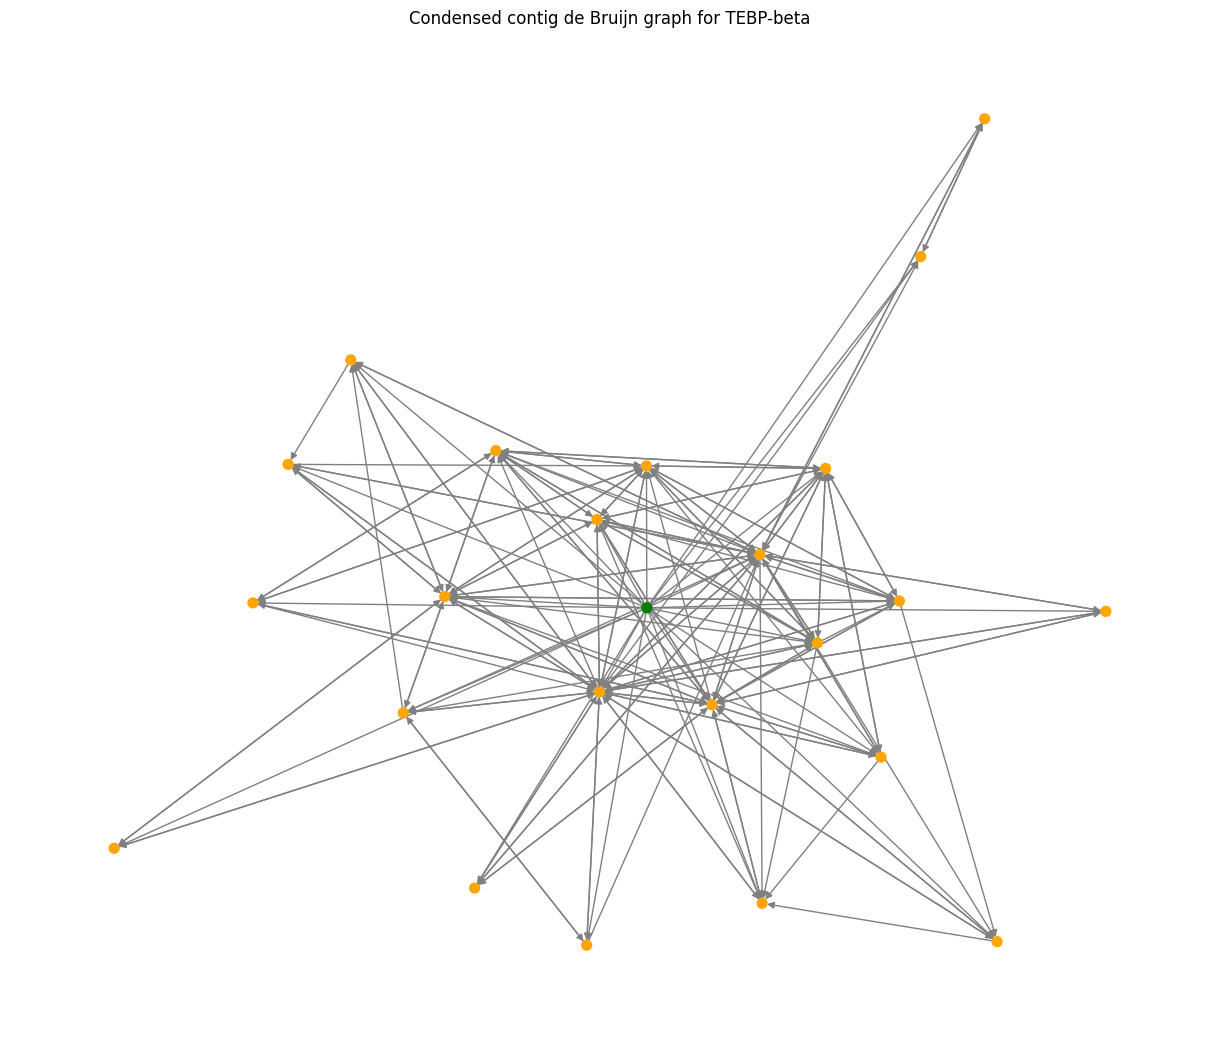

In [ ]:
# visualization for TEBP-beta

import networkx as nx
import matplotlib.pyplot as plt

locus_reference_seq = 'ATGAGTAATTTAACCCATCCAATACAGAAAAGTGTAAATTAAATTTAATAACTTAACAATTACATTTCAGATAAATTCGAACTTTAAAATCTTAAAAAACTTTACCTTTAAATTCATGCTTCAAAACACTATCTAAGACACTTACAATTTTCTCTAAAGTGAAACGAGAAGTGAAAGTTTTTATGAAAAAGTTAGTAATATAATTATTTAGAAGAGTGAGGTTTATATTTGAAAAATTAGGGCAAAAATTAACTCAAACTAATGAGTTATATTCATCAATTAGTACGTATATTAAATTCACTTTATTGGTATCATCAAGAAGTCATCCTGAATCGATTTGATTGCTCATTTCTTGGTTGATCTCTTTGAGGCCTTGGAGGCTTTGCCGGAGGTGGCTGAAGCCTTACCAGCGGATCTCTTTCCGAGGACCTTGCCGCCTGATGAGGTCTTGCCAACATTCTTCTTTTCGTGCCATTCGAGGTATCTCTTGAATTGGGCCATGGTCATTTGATCGGTGGTCTTGGTTGACTTCTTTCCACTTGGGGATGGGTTGGCTGGAAGGGTCTTCTTTGAACCAGTGGTGGTCTTCTTGGCAGATGATTTACCAGCTGGGACTGATTGACTCTTTTGTGGGGTCTCCTTTCTGCTTGATGGCTTGTTGGGAGTGTACTTAACGATCTTGTCAACGCTCTTTCTGACATCGGCTGAAGCACCAACGTCGGCCTTCTTGGCTGAACCCTTCTTTCCTCTGGCAGCTGATTTAGAGGCAGCCTTTGCTTTACCTCTGGCACCACCCTTGACCTTTACGTCTCCTTCTCCGCCTAATTTGCTGAGAGCATCTTTGCCCTTTTCTTGGACGAAAATGTCTTGGATTCTGATGGTAGCAGTGTTGCCTTCTTTGAATGAGAAGTCGGAGAATTCGTCACCCTTGGAGGTGCTGGCTCTGACAATACCGGCATCGACCTTGGCCTTCTTGTCACCACCAGTGACCTTGGCAATATCTGGAATGTTCTCTTGCTTGAGGTTCTTGGCGAGTGATTGCTAAAATCATAATATTAATATATTTGAACTCCTTATTTATAATTCATTTTGACTTAGAAACAGGGAAGAGAGAAATTTATACTTACTTGGAGAGCTTGATGTCTGAAGTGTTGGATGGTGGTCTTGAATTCGTCGTCTCTGTACAAGTTGACTGGGTATCTGGTTGGGTTGAGTCTCTCTTGGAGGTTTGGCTTGAATGAGTGGACGATGAGTCTGGCCTCAAGGTTGGCATAAGAAGTGAAAACCTCAGCTGAGTTGACTCTTCTGAGCTCGAGTGACCAGTTGTTGATAACGATAACCTTGTCGTGGAGGTCGACGATGTTTACGTTGGGGAACTTAGAGTGGAATTCAGTCACGGCCTCCTTGGTGAAGTATGGGGTCACGAAGAAATAACCATCGGTAACAAGGAAATGTGGGTATGATTCTTTGACGTAGCACTTCAATGGCTTCTTTAAGTTGTTTGAGACCTTGCCGAAGTCACCACCGTTGTTGAATAGCTCGGTGTAGAGTTGCTTGAAGGCGCTTTGTTGTTGAACTTGTTGTGATTTGCTCATTATTACTGTGTTTAGAGATTGTTTAAGAAAAGTTTATAAGACTTGTTTTGTTTAAAGTATTGAAAATTAATTTTAGCGCTATCTAAAAATTAAAATTTGATAAATCAATATTTAATTAAAAGCCTTAAAATTATTGGTCTATATCTTGCAAATTGTTATTTTTCAACTTGAAATCATAAATCTTAAACTTGATGTTTGCTCATTATTACTGTGTTTAGAGATTGTTTAAGAAAAGTTTATAAGACTTGTTTTGTTTAAAGTATTGAAAATTAATTTTAGCGCTATCTAAAAATTAAAATTTGATAAATCAATATTTAATTAAAAGCCTTAAAATTATTGGTCTATATCTTGCAAATTGTTATTTTTCAACTTGAAATCATAAATCTTAAAC'

def build_condensed_contig_graph(H: AccumulatedDBG, reads: List[str]) -> nx.DiGraph:

  # Collapses paths into single contig nodes,
  # Returns a directed graph where each node is a contig/path

  G = H.graph

  unitig_paths = extract_potential_contigs(H)

  read_paths = extract_read_supported_paths(H, reads)
  branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H, path)]

  paths_with_class = ([('unitig', path) for path in unitig_paths] +
   [('branch_read_supported', path) for path in branch_read_supported_paths])

  C = nx.DiGraph()
  node_to_contig = {}

  for i, (path_class, path) in enumerate(paths_with_class):
    contig_id = f'{path_class}_{i}'
    seq = path_to_sequence(path, H.k)

    start_kmer = path[0]
    end_kmer = path[-1]

    C.add_node(contig_id,
               sequence = seq,
               length = len(seq),
               start_kmer = start_kmer,
               end_kmer = end_kmer,
               path = path,
               path_class = path_class)

    for node in path:
      node_to_contig[node] = contig_id

  for u, v in G.edges():
    cu = node_to_contig.get(u)
    cv = node_to_contig.get(v)

    if cu is None or cv is None:
      continue

    if cu != cv:
      if C.has_edge(cu, cv):
          C[cu][cv]['support'] += 1
      else:
        C.add_edge(cu, cv, support=1)

  return C

def best_window_identity(query_seq, target_seq):

  # compares contig sequence to reference sequence
  #to get contigs that share regions with reference locus

  query_seq = clean_seq(query_seq)
  target_seq = clean_seq(target_seq)

  qlen = len(query_seq)
  if qlen > len(target_seq):
    return 0

  best = 0
  for i in range(len(target_seq) - qlen + 1):
    window = target_seq[i:i+qlen]
    identity = sum(a == b for a, b in zip(query_seq, window)) / qlen
    best = max(best, identity)

  return best

def add_reference_backbone_by_kmers(C,
                                    reference_seq,
                                    k=25,
                                    min_shared_kmers=1,
                                    allow_rc=True,):
  # adds a backbone to the de Bruijn graph that is one node corresponding to reference sequence

  C2 = C.copy()
  ref_seq = clean_seq(reference_seq)

  ref_kmers = set(kmers(ref_seq, k))
  if allow_rc:
    ref_kmers |= set(kmers(rc(ref_seq), k))

  C2.add_node('reference',
              sequence=ref_seq,
              length=len(ref_seq),
              is_reference=True)

  for v in list(C.nodes()):
    contig_seq = clean_seq(C.nodes[v].get('sequence', ''))

    if len(contig_seq) < k:
      continue

    contig_kmers = set(kmers(contig_seq, k))
    shared = contig_kmers & ref_kmers

    if len(shared) >= min_shared_kmers:
      C2.add_edge('reference',
                  v,
                  support=len(shared),
                  shared_kmers=len(shared),)

  return C2


def plot_condensed_contig_graph(C: nx.DiGraph, figsize=(12, 10), with_labels=True):
  if C.number_of_nodes() == 0:
    print('Condensed graph is empty')
    return

  # colors nodes by branching behavior
  colors = []
  sizes = []

  for v in C.nodes():
    if v == 'reference' or C.nodes[v].get('is_reference', False): # reference contig is green
      colors.append('green')
      sizes.append(800)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)
    length = C.nodes[v].get('length', 1)

    if indeg == 1 and outdeg == 1:
      colors.append('lightgray')
    elif indeg == 0 or outdeg == 0:
      colors.append('red')
    else:
      colors.append('orange')

    sizes.append(max(300, min(3000, length * 20)))

  plt.figure(figsize=figsize)
  pos = nx.spring_layout(C, seed=1)

  nx.draw(C,
          pos,
          node_color = colors,
          node_size = 50,
          edge_color= 'gray',
          with_labels = False,
          arrows=True,)

  plt.title('Condensed contig de Bruijn graph for TEBP-beta')
  plt.show()

def reference_connected_subgraph(C_ref: nx.DiGraph, reference_node='reference') -> nx.DiGraph:
  if reference_node not in C_ref:
    print(f'{reference_node} not found')
    return nx.DiGraph()

  ref_neighbors = set(C_ref.successors(reference_node))
  keep = {reference_node} | ref_neighbors

  return C_ref.subgraph(keep).copy()


H = result['final_graph']
C = build_condensed_contig_graph(H, combined_reads)

C_ref = add_reference_backbone_by_kmers(C,
                                        locus_reference_seq,
                                        k=25,
                                        min_shared_kmers=1,
                                        allow_rc=True,)

def remove_terminal_contigs(C: nx.DiGraph, preserve_reference: bool = True) -> nx.DiGraph:

  # keep only internally connected contigs

  keep = []

  for v in C.nodes():
    if preserve_reference and (v == 'reference' or C.nodes[v].get('is_reference', False)):
      keep.append(v)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)


    if indeg > 0 and outdeg > 0:
      keep.append(v)

  return C.subgraph(keep).copy()

C_ref_only = reference_connected_subgraph(C_ref)

C_ref_internal = remove_terminal_contigs(C_ref_only)

print('reference-connected contigs:', C_ref_internal.number_of_nodes() - 1)
print('reference-connected edges:', C_ref_internal.number_of_edges())

plot_condensed_contig_graph(C_ref_internal, with_labels=False)



##Pol-alpha

In [ ]:
# doing the same as above for the locus pol-alpha
# Case 2, scrambled locus

!pip install biopython

from Bio import SeqIO
MDSs_records = list(SeqIO.parse("/content/drive/MyDrive/oxytricha computational genomics project/sw/pol_alpha_MDSs.fa", "fasta"))
MDSs_sequences = []

for record in MDSs_records:
  MDSs_sequences.append(str(record.seq))

fastq_36 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/pol_alpha_36h_candidate_reads.fastq'
fastq_48 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/pol_alpha_48h_candidate_reads.fastq'

reads_36 = [str(record.seq).upper() for record in SeqIO.parse(fastq_36, 'fastq')]
reads_48 = [str(record.seq).upper() for record in SeqIO.parse(fastq_48, 'fastq')]
combined_reads = reads_36 + reads_48

locus_reference_seq = 'CCCAAAACCCCAAAACCCCAAATGAAAACCCCCCTAGATATTTAGTGAAAATTATTTAATAAAAAGCTCTATTAATATTTGGTGGCATATATATCTACAACCTGAGTGTAAATTGATTTCTTTGATATATGCTCACATATTAACTCTGATTAAAACAAAATATAATAACTTAATACATATATGAACTGTTACTTTTTCATTGTTACTTTCCAAGCTTCATGAAGTTGAATATGCTGCTGAGGTCTACTTTGTTATATTTGCTGCGAATCATAATATCATCGACTTTTCCTTGCATTCTGGCAAATGCATCGAAATTAGGTACTTCCTCTACGGTTTTATGCACACAACCGTTTTTCTGATTTTCTTGGATGTACTTCTTTACATTAAACAAGCCTTATAGATATCTGAGAGTATCATTAGTCTTTTATTCAGTATATTCTGGTATCATTTTTCCCTTGCAAGCTAAATTAATGCATTTGTTGTTATAGAGAAGTTAGCGAGAAACTGCACCACATGCTGGCTCTTGGCATTGCTTGTTACCTTGATAGTATAAAGTTAAGAGCTGCTTTAAGAAAAGAGTGACGCGGTTTTGAATGTAGGCTTCTGGAATTGGCTAGGTGCATTTTATGCAGAGTAAACCTGAGAGAGCATTGTTCTTGCCATCTTGGAAGATTCCTGGGAAGTGATAGCTTTCAGAACAGTGTGGACATTTAATTGTCAACTCAGCTATAGTTCTTCCCTTTAAACTTCTTTCAGTTTCAGTTTACAAGATTGGATTCTAAATCAATGTTCCATCATCATTATTGGTTTCTCCAGTTTTCTTCTCTGAACTGTGATACTTATACTTTTTAGGATCTACTCCTAGGCATTAAGCAACAAATTCCACATCAATACCGTCAATGTGTTCGATAAGTCTGGTAATAGGTGGCAAGACTTGCATAGTGATGTACCACTCAATATCTAGCAAGATTTTTCCTTTAGAGGAGACAACCTCTTCAGGGTGATATGCCTTGTCTGCCAATGCTGGGTTAGTTTTGCTTGGATCAAAAGGCTAAGCACCAATTACATAAGGGATAAAGTTGTTCACTAGATCTGATTCACTCTTTCCTTGATTCTTAAGTCTTTGAGCAACCGCGACATGTGGTTGTCCCTTGATATCTGAGTACTCAGAGATTGCCTTAGTAAGTTGTTTTGTAATGATAAATTGATCCAAGGTGATTCCATTATTTTTCATCTTTTCACCAATATCAGACAAATATTCATTTAAGTTAAGCACAACATCTTCTCTTTGTTTTCCGGATAGAATTTGATTGAGCACAAAGTTACCAACATTCTTTGAAAGTGGGCACCAATCTCTTCTAACCATATCTAGACCTTTAACTTCCTAAACTACTTTAGCATCTGGAGTGCCAAAACCCTCATATTTAAGTGCAGCATACTTCTTTTTCTTAAGAAGTAGTAGACTCTTGAACACACCATCGATTTCTATCTCAAGACACTTATATAAGCAATTAACTTCTGCCTTGAGTCTCTTACCCATTTCTAAAGACTATTGTAATTAATTTGTTCCAGTATTGATCATAATAGAATCAGTATCTCCATATACAACATTGAAACCTAATTTATTCTCAGCAATGTCCTTGGTTCTTAACAGTGTATCTCTTCCAGTTTTGGTAATTAGGGCAGCAATTGCTTAAGCATGGAATCTAGATGAGCCAAAACCAAGGCAACCATACATACTGTTAGCAGTGAGCTTGATAGCTTTTTACCTGATTTCCAGTTGTGAAAGCTTAACTGCGTCCTTCTCGTTCTTCATCTTTTCTTTAACTGCTTTACGTTTCTAAACTAAATCTCTTAAGACATTTGGAAGTACAGCGTCTTTGACATTAACATTCTTATCAGGAAGATCTGCTTCTTCAACTTCATTGCCTTCATTAGCATCTGTTCCAGCAGCCTTGAATTGGCTTTTAACTTCAGACCCATCGAAATTCTTTGTTGGTCTACGATTAACTGTGGTGAAGCATAAATTGTACTCTTGAATAATACTGGGATACAGTGAATTGAAATCCAACAACAAGATAATATTGTCATAGAAACCAGCTTTAGGCTCGATAACCAAACCACCAGCATATGCTGCCTTCTTTCTCTTTCCACCTTTTTTGGGTCCCTTGCCCACTTCAGCCTCTTCAAACTCATCTGCAAACATATTACGCTTGAAATCTTTAGCGTTGGGTGCTTTTTTGTCTGGTAAAATAAACTTCTTCTTTTTGAACTCATGCAATAATAGCATCTCGTTTCTCTCTGCTCTAGCATTTTAGAGAGACCTGAACCATAAGTTACCTGCGATGTTAGTAAGCTGCTTGGTCAAAGGTATAATAGCGAGATGATTCATAAGTTAAATAGTCAAGTAAGCATCTTTTTCAGTGTGATCAATTAGTGAGAAAAGTCTCTCTGAAGTAATGTATAATGTTGGTAAGAGCTCATCATCAAAGTCTTGTCTGTCTTTCTTTAGTTGAACTTTAGCGAGGTAAGTCAAATCATAACTAGTTTCTCTTACAAGCTCCTTAGCAGAAAGGAAAGTATCAACAAGTAATCTACCACATGTGACTTATCTTGGAATCCATTGAGATCCTCCGTAGCTTGAACCTCCTACATCTAGCTTCTTGTTAGGGATTTAAGTCTTCTTTAGTCTTCCAATTCTAGACCAGTGATTAACTTTCAAATATTGAATTCTTGCTAATAACAAATCAAACATTCCTCCACATAAATTGTGAGCAACTACAAGATCTGGATCAACAATGAAAACTTTAGCAATAAATGCTTCTATCATCTATCTCTCATTTTCAAACTTTTGAATGATGTTTTCCTTTCTTTGTTTGACCTTTTGATCAAAGTCATAAGGCATAGGTTTACCATCAAGTTTTCTTAATAAGGTGAATGATTGAGTTCTTTCAACCTGAGAAGGTCCTTCTTGAGCAATGTTTGTATTAATCAAGCATGATATCATAGCAATTTCATTGGTGTTTTATTGAGCTCTGGTGGTTTTAAATGAAAAAGTAAGAGATGTAAGAGGTGGAAGTTCTTACTTATTTAAGTCTTCAAGAGTAACTTCTACGTTCTTTGGGTTATCAATTACAATTTCCTGTCTGCACCATGTTTTCTTGAAATCAGTAACCTTTGTAGGGTTTTTGATTGTCATCCAGCATGGACCTCTAATTTTTCTCTTTAAAATGAATAACTCAAGCATGCTTTAAGTCGACCCAAAAATGCATTCGAATGTGTTTCCTTAAATTGTGCTTGGTAGTGGAGGCATGGTGCTATCATACTTGATTTTCAAGAATTGATGCTCACCATGTTGAATTGGCATTTCAAAAGCGTACTTTCTATTAACTGGCTTGCATCTCCATTTTGAAATTTGAGGGAATCTCTTCTTTCTAATATCATCCAACTCCATCATTACAGCTCTTACTTATTCCTTCTCTTCTTCAACAGTCAAAGCTCCTCTTGCTTTACCTCTCATTTTAGGGAGAGCATAGAGTTCTCTTTGCATTCCATTAACTTTCATAGAGCAAGAAACGAATTATCTCACTTGTGGTTGATAGATTTTTCCAAAAATATACAGATCTGTTCCATTATTTTCTTCATGAGCATCGATCCAATAGAATGATAATGTACCATTTTCGTTTAGAGGAAGTGGAAATTCTTGAGTATTTTAACCAACACTTGGTTCCATATTTCTAAGTTCCTAATTGGCTTAGAAGTTTTGTTGTCTAACTTAATTCCACTCATCATTTGATTTTGATTATGTCTCTAAAGTCTTGCTGTGGTTCACTGTCTATTCAATTTAAGTTTTTTTCTAAGCTGAAGTCTAGTCGATTTTCATTGAGTCATCCATAGCGCTTTAAAAGTCACTTTAATTTAAGGATTCGCTACTTTTAGCATCGAAATAACTTGTGTTTCCACTTTTGTTCAAATTATCATTAGTTTAGTTTGAAACTCTTTTGGAATCGGATGCAAGAGCATTTTAGTTAGTGGAAATCTCTTCAAACTTTCTCTTTTTTGAAAATGGATTGGAACTTTGTTGGTTCTATCCAATCTAGGCTTATGCCTAAATTTGCTCTGTGACCCTCTTCTATTCAACTTCTTAGCGAGTTTCAAGTGTAACTGCATATTTCGAGGTCAGCATATCGTTCTAATTGAAAGCAATTGGTTTGTTAAGCTCGGTAACAACTGCTGAATTATTTACATCTTAGAGTTCATCTACATCCTTTGAATCAAGTTCTTAGAAGAGATTGTTCATGATGTCCTTTGACTACTCAGCTGAAACCTTGGGTTTTTGCTTGATTTAGGCACTGGAGTTTGTCACAGCTCCTGGTCTGTTTATAGTTGACTTTGGCTTCATAAAGGCAGTGATTGACTGTTCATTAGGCTATAAGAATAAAGGTTAAGCATTAAAATTGAGATGAGAATGAAATAACGTACATCGAGCTTTCTCTTTTTCTTTTTACCGCCATCTTCAGGGTGGTCATCTCTTTCCCAAATTTCACCTCCGTGATCTCTGTAACCATAACCATCGTCGTCAACAATGAAGTCATCGTTCTTTCTTTGATCTTAAATTTTGTCATATTCGTCGTCATCTATCTCATCAAATATTTTCTTGGCTTCATCAACCTAAAGGTAAAATTGAGCAAAACTGTTTGAAAATTAAATTTCTACATTTTCCAATAATAAATGGAACATCACTTACCTAATACTGATCAGTTCTTTTGCTTCCTCCTTCTCTAGCAGCTCTCAATTGAGCTAGGGCGCCTTTGGCAGCATCTCCACGACCTGCTTTCTTAATCTCTCTTCCTGATTGTGTTGTGTACTTATCGCTCATAAATAATTGTTTTTTAGTAAAATCGCAAACTAGACTGTTCACAAATGTTGCAAATTTTAAATTATATATAGATTAAACGCGGTATTTAATTTACTTATTCCCCTACTATTTTGAATTGAGGGGTTTTGGGGTTTTGGGG'
MIC_reference_seq = ["TAAGTTATTCACTATATTAATCACATCCATATCGCAACTTAAACAATAAATCTATAACTCACTATCATAAACTGACCCCAAACATCGCATATACTCACTTAAAATACTAATATTTAAACATTAAACCCCTACATAAACCCTATTAAAACCCTAATAAAGTATGCCTTAATAGTCTACTTTTATCAATCAAACTACTGAAAGGGTTTTGGGGTTTTGATTCTTTGAAAGTAGTTACTTACACTTTTTTTTAATTTACTATATATAACGATAAAACTAAATTTTATCATTTAAATATTTGTTATAATTATCATTGATCCTAAACTACTTTAGCATCTGGAGTGCCAAAACCCTCATATTTAAGTGCAGCATACTTCTTTTTCTTAAGAAGTAGTAGACTCTTGAACACACCATCGATTTCTATCTCAAGGAAAATATAAAATGTTTTTTCAATAATATTACAAAATAGAATCAGTATCTCCATATACAACATTGAAACCTAATTTATTCTCAGCAATGTCCTTAAATATGTAGTGTATCTCTTCCAGTTTTGGTAATTAGGGCAGCAATTGCTTAAGCATGGAATCTAGATGAGCCAAAACCAAGGCAACCATACATACTCAGCTTTAAATAATTTTGAAAATAATCTCATTAATAATAATTTTATTAATTTTTAGAATTAGTCAAAGTCTTGTCTGTCTTTCTTTAGTTGAACCATATTGAGTATTTTAATAAATTATCTTGGAATCCATTGAGATCCTCCATGTGATAATGTTTTTGGATTCTAGCTTCTTGTTAGGGATTTAAGTCTTCTTTAGTCTTCCAATTCTAGACCAGTGATTAACTTTCAAATATTGAATTCTTGCTAATAACAAATCAAACATTCCTCCACATAAATTGTGAGCAACTATATACTGTGAATTAAAAAATTAATGCTATAATAATTTAAGTATTCTATCTCTCATTTTCAAACTTTTGAATGATGTTTTCCTTTCTTTGTTTGACCTTTTGATCAAAGTCATAAGGCATAGGTTTACCATCAAGTTTTCAATAAATAATAGATGTAGATAAGTAATATGATATCATAGCAATTTCATTGGTGTTTTATTGAGCTTATAAATAATTATTCCAGTCAATATAAAAAAATAATACAAGAGTAACTTCTACGTTCTTTGGGTTATCAATTACAATTTCCTGTCTGCACCATGTTTTCTTAAATTTAAGGCTTAATTATTAATTCAAGCATGCTTTAAGTCGACCCAAAAATGCATTCGAATGTGTTTCCTTAAATTGTGCTTGGTAGTGGAGGCATGGTGCTATCATACTTGATTTTAAAATTATACTTAGAGATTATTCTCACCATGTTGAATTGGCATTTCAAAAGCGTACTTTCTATTAACTGGCTTGCATCTCCATTTTGAAATTTGAGGGAATCTCTTCTTTCTAATATCATCCAACTCCATCATTACAAGATTTAGATAAATTTCTATGTAGAATTTAAATCTCCTCTTGCTTTACCTCTCATTTTAAGCAACTAGAAATATTTTTATTAACAATTTGCATTCCATTAACTTTCATAGAGCAAGAAACAAATTAAATCTTTATGCTTATTATTTTCTTCATGAGCATCGATCCAATAGAATGATAACTATATTATAAATAACACTCTAAACATATTTCTAAGTTCCTAATTGGCTTAGAAGTTTTGTTGCATCAATAATTATTTATTAAGGTTTTTAGCTTTAATTCCACTCATCATTTGATTTTGATTATGTCTCTAAAGTCTTGCTGTGGTTCACTGTCTATAATTTTATTAAAATTATCCTAAAAAAAGATTAATAGTTTATTATATTCAATTTAAGTTTTTTTCTAAGCTGAAGTCTAGTCGATTTTCATTGAGTCATCCATAGCGCTTTAAAAGTCACTTTAATTTAAGGATTCGCTACTTTTAGCATCGAAATAACTTGTGTTTCCACTTTTGTTCAAATTATCATTAGTTTAGTTTGAAACTCTTTTGGAATCGGATGCAAGAGCATTTTAGTTAGTGGAAATCAAAAACAAAGAATTCGTTATAATAAATTTAATTTATTGTTTATATTAATTAAAAGATAACAAGTATTCTATCATTAAAATTAAATGGGAGATTTATATAAACAGTCAGAAAAAAATAATCATCTATAATAGATAAACTCTTATTCAGAAAATATTTGATTGGATTATTTTATCTAACTATTATTAGGGAATTTATTTGCATTTACTCTGAAGAACTAAAAGAATTAGGATTCTTTGGAGCAAAGTATTAAAAATGCATAAAATTAAAGAAATAAATAGAAAAAGAAAAATGCATTTTAAGTCCTAATATAATTATTGGGATTCTAAATCTCTTCAAACTTTCTCTTTTTTGAAAATGGATTGGAACTTTGTTGGTTCTATCCAATCTAGGCTTATGCCTAAATTTGCTCTGTGACCCTCTTCTATTCAACTTCTTAGCGAGTTTCAAGTGTAACTGCATATTTCGAGGTCAGCATATCGTTCTAATTGAAAGCAATTGGTTTGTTAAGCTCGGTAACAACTGCTGAATTATTTACATCTTAGAGTTCATCTACATCCTTTGAATCAAGTTCTTAGAAGAGATTGTTCATGATGTCCTTTGACTACTCAGCTGAAACCTTGGGTTTTTGCTTGATTTAGGCACTGGAGTTTGTCACAGCTCCTGGTCTGTTTATAGTTGACTTTGGCTTCATAAAGGCAGTGATTGACTGTTCATTAGGCTATAAGAATAAAGGTTAAGCATTAAAATTGAGATGAGAATGAAATAACGTACATCGAGCTTTCTCTTTTTCTTTTTACCGCCATCTTCAGGGTGGTCATCTCTTTCCCAAATTTCACCTCCGTGATCTCTGTAACCATAACCATCGTCGTCAACAATGAAGTCATCGTTCTTTCTTTGATCTTAAATTTTGTCATATTCGTCGTCATCTAAACTTTTAGCTCATAATTTACTTTAAATTGTGTTAATCTGTTAACCTTTATCTCATCAAATATTTTCTTGGCTTCATCAACCTAAAGGTAAAATTGAGCAAAACTGTTTGAAAATTAAATTTCTACATTTTCCAATAATAAATGGAACATCACTTACCTAATACTGATCAGTTCTTTTGCTTCCTCCTTCTCTAGCAGCTCTCAATTGAGCTAGGGCGCCTTTGGCAGCATCTCCACGACCTGCTTTCTTAATCTCTCTTCCTGATTGTGTTGTGTACTTATCGCTCATAAATAATTGTTTTTTAGTAAAATCGCAAACTAGACTGTTCACAAATGTTGCAAATTTTAAATTATATATAGATTAAACGCGGTATTTAATTTACTTATTCCCCTACTATTTTGAATTGAAAAATAAATATATGGATTTCAGATAATGAGTGGAATTAAGTTAGACAACATAACATTTAAATATATAAATTATAAAGAAATATGGAACCAAGTGTTGGTTAAAATACTCAAGAATTTCCACTTCCTCTAAACGAAAATGGTACATTATCATTATAGTCATAGTATATAAATAAAATAATGGAACAGATCTGTATATTTTTGGAAAAATCTATCAACCACAAGTGAGATAATTCGTTTCTTGATTATTATTTTAAAAGAAATCTTGGATGCAAAGAGAACTCTATGCTCTCCCTAAAATGATATAATTTTTCATTTTTAGAGGAGCTTTGACTGTTGAAGAAGAGAAGGAATAAGTAAGAGCTGTAATGATGGAATTAAAATAACATTTTCTCAATGCTTTATGGTGAGCATCAATTCTTGAAAATCAATGTTAATTACTAATATCAAAGCATGCTTGAGTTATTCATTTTAAAGAGAAAAATTAGAGGTCCATGCTGGATGACAATCAAAAACCCTACAAAGGTTACTGATTTCAAGAAAAATGTAAATATGAATTTAAATTTATAATCAAGTTACTCTTGAAGACTTAAATAAGTAAGAACTTCCACCTCTTACATCTCTTACTTTTTCATTTAAAACCACCAGAGCTCAATAAAATATTTATTAAATTATCAAAGTAATTTAACTCAATTTTATATGATATCATGCTTGATTAATACAAACATTGCTCAAGAAGGACCTTCTCAGGTTGAAAGAACTCAATCATTCACCTTATTAAGAAAACTTTAACATAAATTATAAATCCGTTTAGAGAGATAGATGATAGAAGCATTTATTGCTAAAGTTTTCATTGTTGATCCAGATCTTGTAGTTGCTCTTTTAATAGATTTTTAATGATTATTCAAAATAAAGCTAGATGTAGGAGGTTCAAGCTACGGAGGATCGTTTTATTTGCAAGATAAGTCACATGTGGTAGATTACTTGTTGATACTTTCCTTTCTGCTAAGGAGCTTGTAAGAGAAACTAGTTATGATTTGACTTACCTCGCTAAAGTTCAACTTAGATCCATTAATTAATCATAAGACTTTGATGATGAGCTCTTACCAACATTATACATTACTTCAGAGAGACTTTTCTCACTAATTGATCACACTGAAAAAGATGCTTACTTGACTATTTAACTTATGAATCATCTCGCTATTATACCTTTGACCAAGCAGCTTACTAACATCGCAGGTAACTTATGGTTCAGGTCTCTCTAAAATGCTAGAGCAGAGAGAAACGAGATGCTATTATTGCATGAGTTCAAAAAGAAGAAGTTTATTTTACCAGACAAAAAAGCACCCAACGCTAAAGATTTCAAGCGTAATATGTTTGCAGATGAGTTTGAAGAGGCTGAAGTGGGCAAGGGACCCAAAAAAGGTGGAAAGAGAAAGAAGGCAGCATATGCTGGTGGTTTGGTTATCGAGCCTAAAGCTGGTTTCTATGACAATATTATCTTGTTGTTGGATTTCAATTCACTGTATCCCAGTATTATTCAAGAGTACAATTTATGCTTCACCACAGTTAATCGTAGACCAACAAAGAATTTCGATGGGTCTGAAGTTAAAAGCCAATTCAAGGCTGCTGGAACAGATGCTAATGTCAAATAATAACATATTCAAATTCATTAATCTATAATGCCTAGTTTATTTATTCTAATGAAGGCAATGAAGTTGAAGAAGCAGATCTTCCTGATAAGAATGTTAATGTCAAAGACGCTGTACTTCCAAATGTCTTAAGAGATTTAGTTTAGAAACGTAAAGCAGTTAAAGAAAAGATGAAGAACGAGAAGGACGCAGTTAAGCTTTCACAACTGGAAATCAGGTAAAAAGCTATCAAGCTCACTGCTAACAGTATGTATAGTTAATTTATTATAAAAAACTCCAAATAAATTCAAATTAGGATTTTACATTACAGAGATACACTGTTAAGAACCAAGGACATTTATAAAATAACTGATATAAAAGATTCTATTATGATCAATACTGGAACAAATTAATTACAATAGTCTTTAGAAATGGGTAAGAGACTCAAGGCAGAAGTTAATTGCTTATATAAGTGTCTTGAGATTTAAAAAAGAATTTTATCGATAAAAATAACGTCTAAATCTTATAAATTAACAAGAAAATTATAATTAAAAGTAGTTTAGGAAGTTAAAGGTCTAGATATGGTTAGAAGAGATTGGTGCCCACTTTCAATAATTAATGTAACAAATTATCTTAATGAAAAATAATGGAATCACCTTGGATCAATTGATTATATTAAAATTGCTTAACATTTTATTGAATATAAGAGTGAATCAGATCTAGTGAACAACTTTCATATGACATTAAGAAGAATTAATTGAGACAATAATTGTTTTGAACAGCATTTTAAAATACACATATATTAAAGAATCTTATAAGATTACTATTTTATAGCAATTTAATTTGGGAAAAAAATCTGGTTTAAAATATATATTTTTACAAAAGTAGCTTATCAAATTCTTGTTTTACAAAATAGAGATTTTTTTATGTAATGG"]


result = iterative_assembler(
    reads=combined_reads,
    reference_seq=locus_reference_seq,
    k_min=25,
    k_max=50,
    m=1,
    prune_dead_ends=False,
    final_branch_traversal=False,
    verbose=True,)

H = result['final_graph']


unitig_contigs = result['unitig_contigs']
branch_read_supported_contigs = result['branch_read_supported_contigs']
final_contigs = result['final_contigs']

print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

import pandas as pd

print('\nUnitig contig lengths:')
print(pd.Series([len(c) for c in unitig_contigs]).describe())

print('\nBranch read-supported contig lengths:')
print(pd.Series([len(c) for c in branch_read_supported_contigs]).describe())

print('\nFinal combined contig lengths:')
print(pd.Series([len(c) for c in final_contigs]).describe())


[k=25] vertices=69982 edges=70767
first read length: 10076
unitig contigs: 2381
reads used as support: 28
longest unitig: 2935

[k=26] vertices=70767 edges=71539
first read length: 10076
unitig contigs: 2343
reads used as support: 28
longest unitig: 2936

[k=27] vertices=71539 edges=72296
first read length: 10076
unitig contigs: 2301
reads used as support: 28
longest unitig: 2937

[k=28] vertices=72296 edges=73039
first read length: 10076
unitig contigs: 2259
reads used as support: 28
longest unitig: 2938

[k=29] vertices=73039 edges=73772
first read length: 10076
unitig contigs: 2236
reads used as support: 28
longest unitig: 2939

[k=30] vertices=73772 edges=74494
first read length: 10076
unitig contigs: 2193
reads used as support: 28
longest unitig: 2940

[k=31] vertices=74494 edges=75203
first read length: 10076
unitig contigs: 2161
reads used as support: 28
longest unitig: 2941

[k=32] vertices=75203 edges=75896
first read length: 10076
unitig contigs: 2115
reads used as support: 

In [ ]:
# saving de Bruijn graph for pol-alpha

import copy
import pickle
import os

outdir = '/content/drive/MyDrive/oxytricha computational genomics project/idba_outputs'
os.makedirs(outdir, exist_ok=True)

locus_name = 'pol-alpha'

H_saved = copy.deepcopy(H)
result_saved = copy.deepcopy(result)
combined_reads_saved = combined_reads.copy()

# simple, non-branching paths:
unitig_paths = extract_potential_contigs(H_saved)
unitig_contigs = [path_to_sequence(path, H_saved.k) for path in unitig_paths]

# read-supported paths, but only if they pass through a branch:
# (read support used to resolve branches)
read_paths = extract_read_supported_paths(H_saved, combined_reads_saved)
branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H_saved, path)]
branch_read_supported_contigs = [path_to_sequence(path, H_saved.k) for path in branch_read_supported_paths]

# combined final set:
final_contigs = unitig_contigs + branch_read_supported_contigs

globals()[f'H_{locus_name}'] = H_saved
globals()[f'result_{locus_name}'] = result_saved
globals()[f'combined_reads_{locus_name}'] = combined_reads_saved
globals()[f'unitig_contigs_{locus_name}'] = unitig_contigs
globals()[f'branch_read_supported_contigs_{locus_name}'] = branch_read_supported_contigs
globals()[f'final_contigs_{locus_name}'] = final_contigs

with open(f'{outdir}/{locus_name}_H.pkl', 'wb') as f:
  pickle.dump(H_saved, f)

with open(f'{outdir}/{locus_name}_result.pkl', 'wb') as f:
  pickle.dump(result_saved, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.pkl', 'wb') as f:
  pickle.dump(unitig_contigs, f)

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.pkl', 'wb') as f:
  pickle.dump(branch_read_supported_contigs, f)

with open(f'{outdir}/{locus_name}_final_contigs.pkl', 'wb') as f:
  pickle.dump(final_contigs, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.fa', 'w') as f:
  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_final_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

print(f'Saved graph and contigs for {locus_name}')
print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

Saved graph and contigs for pol-alpha
unitig contigs: 1604
branch read-supported contigs: 28
final combined contigs: 1632


reference-connected contigs: 28
reference-connected edges: 205


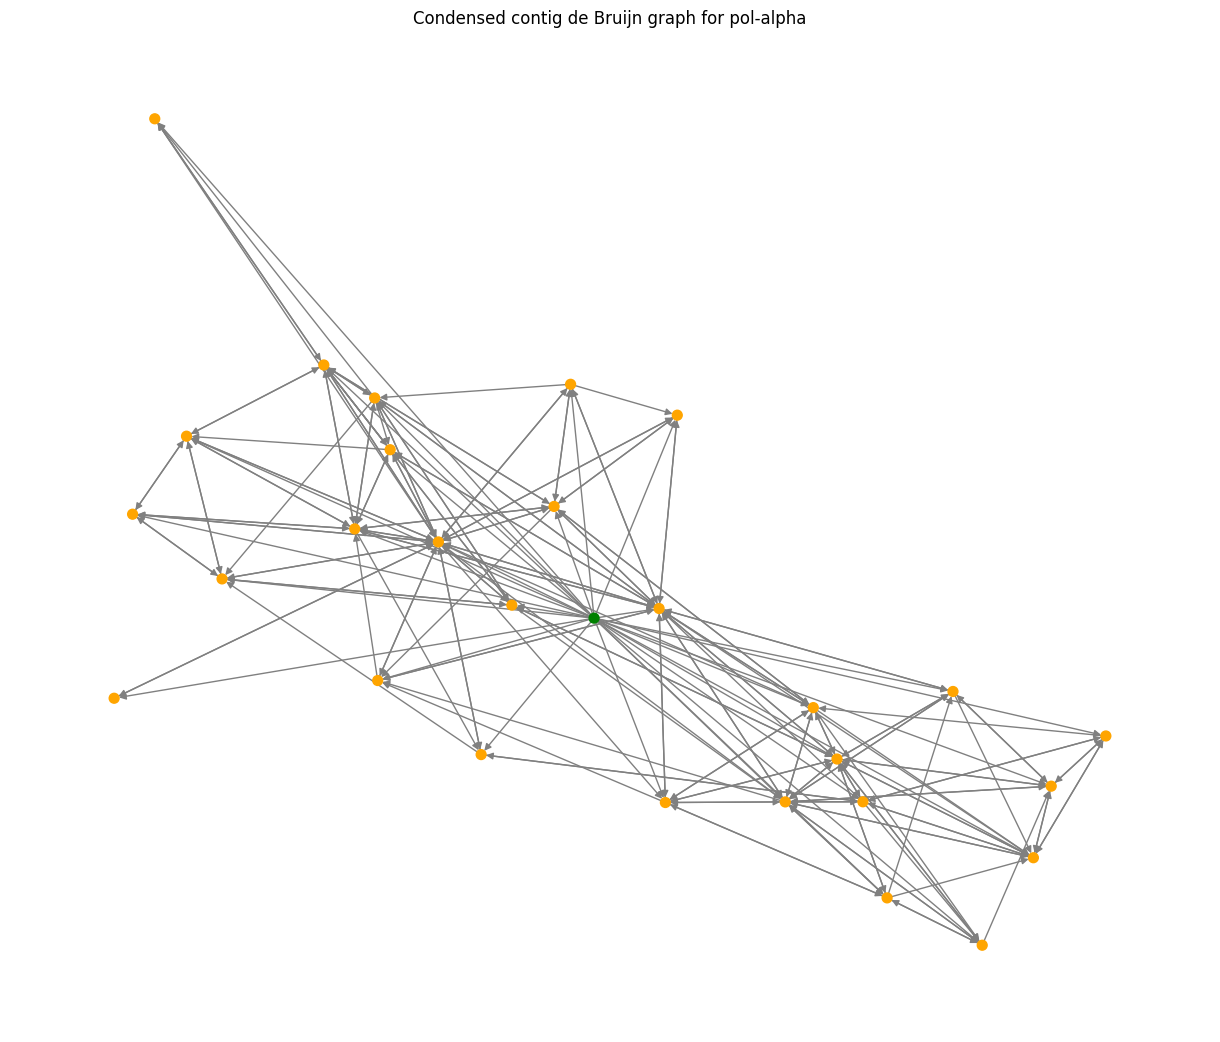

In [ ]:
# visualization for pol-alpha

import networkx as nx
import matplotlib.pyplot as plt

def build_condensed_contig_graph(H: AccumulatedDBG, reads: List[str]) -> nx.DiGraph:

  # Collapses paths into single contig nodes,
  # Returns a directed graph where each node is a contig/path

  G = H.graph

  unitig_paths = extract_potential_contigs(H)

  read_paths = extract_read_supported_paths(H, reads)
  branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H, path)]

  paths_with_class = ([('unitig', path) for path in unitig_paths] +
   [('branch_read_supported', path) for path in branch_read_supported_paths])

  C = nx.DiGraph()
  node_to_contig = {}

  for i, (path_class, path) in enumerate(paths_with_class):
    contig_id = f'{path_class}_{i}'
    seq = path_to_sequence(path, H.k)

    start_kmer = path[0]
    end_kmer = path[-1]

    C.add_node(contig_id,
               sequence = seq,
               length = len(seq),
               start_kmer = start_kmer,
               end_kmer = end_kmer,
               path = path,
               path_class = path_class)

    for node in path:
      node_to_contig[node] = contig_id

  for u, v in G.edges():
    cu = node_to_contig.get(u)
    cv = node_to_contig.get(v)

    if cu is None or cv is None:
      continue

    if cu != cv:
      if C.has_edge(cu, cv):
          C[cu][cv]['support'] += 1
      else:
        C.add_edge(cu, cv, support=1)

  return C

def best_window_identity(query_seq, target_seq):

  # compares contig sequence to reference sequence
  #to get contigs that share regions with reference locus

  query_seq = clean_seq(query_seq)
  target_seq = clean_seq(target_seq)

  qlen = len(query_seq)
  if qlen > len(target_seq):
    return 0

  best = 0
  for i in range(len(target_seq) - qlen + 1):
    window = target_seq[i:i+qlen]
    identity = sum(a == b for a, b in zip(query_seq, window)) / qlen
    best = max(best, identity)

  return best

def add_reference_backbone_by_kmers(C,
                                    reference_seq,
                                    k=25,
                                    min_shared_kmers=1,
                                    allow_rc=True,):
  # adds a backbone to the de Bruijn graph that is one node corresponding to reference sequence

  C2 = C.copy()
  ref_seq = clean_seq(reference_seq)

  ref_kmers = set(kmers(ref_seq, k))
  if allow_rc:
    ref_kmers |= set(kmers(rc(ref_seq), k))

  C2.add_node('reference',
              sequence=ref_seq,
              length=len(ref_seq),
              is_reference=True)

  for v in list(C.nodes()):
    contig_seq = clean_seq(C.nodes[v].get('sequence', ''))

    if len(contig_seq) < k:
      continue

    contig_kmers = set(kmers(contig_seq, k))
    shared = contig_kmers & ref_kmers

    if len(shared) >= min_shared_kmers:
      C2.add_edge('reference',
                  v,
                  support=len(shared),
                  shared_kmers=len(shared),)

  return C2


def plot_condensed_contig_graph(C: nx.DiGraph, figsize=(12, 10), with_labels=True):
  if C.number_of_nodes() == 0:
    print('Condensed graph is empty')
    return

  # colors nodes by branching behavior
  colors = []
  sizes = []

  for v in C.nodes():
    if v == 'reference' or C.nodes[v].get('is_reference', False): # reference contig is green
      colors.append('green')
      sizes.append(800)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)
    length = C.nodes[v].get('length', 1)

    if indeg == 1 and outdeg == 1:
      colors.append('lightgray')
    elif indeg == 0 or outdeg == 0:
      colors.append('red')
    else:
      colors.append('orange')

    sizes.append(max(300, min(3000, length * 20)))

  plt.figure(figsize=figsize)
  pos = nx.spring_layout(C, seed=1)

  nx.draw(C,
          pos,
          node_color = colors,
          node_size = 50,
          edge_color= 'gray',
          with_labels = False,
          arrows=True,)

  plt.title('Condensed contig de Bruijn graph for pol-alpha')
  plt.show()

def reference_connected_subgraph(C_ref: nx.DiGraph, reference_node='reference') -> nx.DiGraph:
  if reference_node not in C_ref:
    print(f'{reference_node} not found')
    return nx.DiGraph()

  ref_neighbors = set(C_ref.successors(reference_node))
  keep = {reference_node} | ref_neighbors

  return C_ref.subgraph(keep).copy()


H = result['final_graph']
C = build_condensed_contig_graph(H, combined_reads)

C_ref = add_reference_backbone_by_kmers(C,
                                        locus_reference_seq,
                                        k=25,
                                        min_shared_kmers=1,
                                        allow_rc=True,)

def remove_terminal_contigs(C: nx.DiGraph, preserve_reference: bool = True) -> nx.DiGraph:

  # keep only internally connected contigs

  keep = []

  for v in C.nodes():
    if preserve_reference and (v == 'reference' or C.nodes[v].get('is_reference', False)):
      keep.append(v)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)


    if indeg > 0 and outdeg > 0:
      keep.append(v)

  return C.subgraph(keep).copy()

C_ref_only = reference_connected_subgraph(C_ref)

C_ref_internal = remove_terminal_contigs(C_ref_only)

print('reference-connected contigs:', C_ref_internal.number_of_nodes() - 1)
print('reference-connected edges:', C_ref_internal.number_of_edges())

plot_condensed_contig_graph(C_ref_internal, with_labels=False)





##Serine Threonine Kinase

In [ ]:
# now for serine threonine protein kinase
# Case 3, scrambled locus, gene segments coming from two different precursor chromosomes

!pip install biopython

from Bio import SeqIO
MDSs_records = list(SeqIO.parse("/content/drive/MyDrive/oxytricha computational genomics project/sw/st_kinase_MDSs.fa", "fasta"))
MDSs_sequences = []

for record in MDSs_records:
  MDSs_sequences.append(str(record.seq))

fastq_36 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/st_kinase_36h_candidate_reads.fastq'
fastq_48 = '/content/drive/MyDrive/oxytricha computational genomics project/sw/st_kinase_48h_candidate_reads.fastq'

reads_36 = [str(record.seq).upper() for record in SeqIO.parse(fastq_36, 'fastq')]
reads_48 = [str(record.seq).upper() for record in SeqIO.parse(fastq_48, 'fastq')]
combined_reads = reads_36 + reads_48

locus_reference_seq = 'AATAACGCTTTGTCATCTAAACCAACATTCAAACCCTCCACCAATCCCCATTATTAAATTAAGTTAAAAAGATTGGATTATAGGGTTAAACTTATAAAATAAAGCTTATTTTCAATTTTGAGAGAACAATCTTCTCCTTATTTAAATACTATTACGATATAAAGGTGATTTCACTAGCAATTTATTAGAATTTTACCCTCGGAGGCAACGGCAACTCTCTCCTCCATCCCTTCTAGGTAGTGTTCAAGAGACACTTCCTTGACGATATTTGTCCCAAATATTTTTCCACCATCTCTCAAATCATTAGAAACTCTTTAGAATACTGCTTATCTTTCATCGTTAGATAGCGATTAGAGATAATTGAACAATGAGAAAGCTACAATTGATTTACTTTGAAAAAGAATACTTCCAGTGTTTACAATCAAGGGATCTTCTGTCAAAGTGCCCACAATAGAGCATTAAGATCCGAGTGGCATCAACTCAATCAATTTGCCTGATATCACACCTCCAATGTAATCAAACATGATAGTTGGCTTCAAAAGCTCAATTAGTTCCTTCACATCTTCATAAAAAGTTTCAGAAGTCTGATTGAGCACGTATTTAGCATTGAGTTCTTGCTTGAGTTGTCTTACTTGCTCATCTTTTCTGACAATATTTATTACTTCAATACCCTCTTCATGGCATAATCTATAGAATTGCTTTGCAAGTTAAGATGAAGCTGCGGTCATAATGCAAGAAGGGGATTTTCTCTATTGAACTATGTGCAGTTGACCAAGAGCAGTCAATGGATTTACTTGGGCATTTGCAGCTTTTGCCAAATCTTGAGTTTCATCCAAAATGATCAAATTCTCTGGCTTGTCTATCTTGTATTGAGTCCATGCACCTCCCATAAGTGAAACTTTCTTTCCAACTAAGCCTGAATCTACGTTATCTCAAACTGCAACTATGATTCCAGAACCATCGGATCCGATTTTCTCTGGCTTGAAAACATAGTACAAATATTTATCATAGGGATTGATGGTTGAGTAAGCTACTTTGATAAGCACTTCACCTGAGGCTGGCTCTGGAATTGTTTCAGTTTTAATTTGATAATTTCCTTCGGTTAGCCCTACAAATTTATAAGTTTTTTCTTATGATTGATCAACCATTATTTTGATATGAATGAATTAATGACTTAAAGATATTAAAGATTTATACTAATATTTTAGGATTTATAATAAATGTTAAGAAGTTAATTACGTGTTTAAATTAAAGATATTCCTTAATAAATTAAAATTAATGATGATTGATTACCTTTCTTGCTTAACATTAAAGGGTTAAGTTTGAAAGTACTTATTAGCTCATTTCAAAATGATTAGAACTTTGAATGATTTCTTCCTCATTGGCAGTTAATGAGAATTTTTCCTTCAGTAGCAACGGCAGCTCTCTCAGCCATACCTTCTTGGAATTGCTCGAAAGAAATTTCCTTAACAATCTGAGTTCCAAATATCTTTCCTCCATCTCTGAGATCATCGGCTAATCTCTTGTAAGCAGCTTGTCTTTCTTCCTCGGTAAGCTCCTTCAAGTAAGGAGTCAAAAGGAAGCCTCTTACGGTTTTATTTGAGAATATGATGTTGCCTGAATTAAGGTTCAGGGTCTCCCCTGATAAGTTTCCAACAACAACTAAATGGGAACCAGCTTCCATGACTGCGAAGATTTTGCCTGGAAGGTCACCGCTCACATACTCAAACATAACCTTGGGATGAAGTTAATTGATTAATGCCTAAAGATCCTCAAAAAAGGTTTCTGAAGTTTGATTGAGCACGTATTTAGCATTAAGTTCTTCCTTGAGTATCTTAACTTACTCATCCTTTCTGACAATATTGATTACTTCTATACCCTCTTCCTGACTTAACTTGAGGAACTGTTTGGCAAGTTGAGATGACGCAGCCATCATAATGCATGAGGTAGATTTCTACTTCTTGACGATATCCAATTGGCCAATGACAGTCAATGGATTCACAATGGCATTAGCTGCCTTTGAAAGGTCTTGTGAGTCATCTAAGATAACTAAACCTTCGGGCTTTGCAAGTTTATATTGTCCCCATGCTTCATAAGTGAAAGCAACCTTTTTCCCATTAAGCTCTGGGTTAACTCCTTCACCTAGAGCAACAATAGTTCCACATCCATCTGAGCCAACTCTTGGTTGAGTAAAAGTATAGAAAGTGTACTTATCAACTGGGTTGATTGTTGAGTAAGCAATTCTAATGAGAACTTCTCCTGGGCCTGGTTTAGGGATTGGAGCTGTTTTTACTTAGTAGGATTTGTCTACAAGACCCACAAACTTGAAAGTTTCTTCGACTTATTCAACCATAGTATTAAGTTTTGATATTTAAAGATATTCTATTATTAGATCAATAACGTAATTTAAATTGAATGTAAAGGTATTCTAACTTTAAAAACACGTGGATTTTTACCAATGGGGTTTTGGGGTTTTGGGGTTTTGG'
MIC_reference_seq = ["AGCTCAATTAGAAAGTCATAATTGACGTACCACCACTTCACCTTGCAATAAAAATTTTAATTTAATAATTTAGATTAAAAATTAAATTTCTTAATTAATAATAAAATCTATAAAATTAAATAAATTGAAAAATTAAAAGCCAGAAAATTTTCCATTTTACAGGTAACTTTATTCCCCCCCCCAAAATTTATTAATAAATATAAAAAAATTATTATTTTTATACAGAATAAGTATAACATAGCATTAATTTTAAGCTGAAGAAGTTAATTTTATTTAACATTTTAAAATTTAACATTAGTATTTAGTAAAGAGAAAATATATTTATTAGATAAGATAAAAAGATTAAGAATATAGAAATAATCTAAATTAAAAATATTGAATCCTTAAACACCGAACCCCATGATTATTAATAGAGAGAGATTAAATTAATAAATTGTTAATCATAAATACAAGTTAATTTTAAATTTAATCAAAATATAAATCAGAGATCTTTTATAACTTCTTCTTTCTTTTCTTCCTCTTTGATTCAAACTATTAATTTATCCTATAAGGCTTTTAAGATTTAATCAATAGAACTTTATATTGTTTCCATTTTTATTTCTAAATTTTAAATTAAGGTTTCTTAATTTTTATTTGAGATTTCTAAAATTTTATTTGAGGTTTATAAATTTTTATTTGAGGTTTCTTAGTTTTTAATTTATGTTTCTAAACTTTTAATTAAGGTTTCTTAATTTTTATTTGAGGATTCTAATTTCTAATTAATGCAAAAATATAATATAATTGGGGAAATCATAAATAATAATCAACAACAATAAAAATTAAATTTTAAATAATTATAACTGCCTCTATTAAGACATTCTTTTAGATCAAATTTGATTCTAGATACTTACCTTTATGCTTAAAAAAGGTAAACCGTATTTATCAATTATGCTTACGGAGAAAGTCTAATTTTGTAGTTGTGACCCTAATCATTTGACAGTATTTCAAGTCTAAGTATTTGACCATTTGACCAATTTATGCAAGTGTCTTTGTGGTCATGAGATAAGTATCTAAATATGCGGGATAATTATTTATTATTTTAAGAATTAAATATAGTGAATAATACAAGCAGAGGAAATTAAAAGTCTCTCGATCATCAATCTGATTATACTTTTTAATGTTCTTTCTCAATAATTGCGTTCTCTGCTAATATTTTACTCCTATGAATAGCGTGCCATAACGTACTTTACGAATTTAATCGTGTAAAATGGGAACTTAAATGGTCTCTTTTCACTTCTCATTGCTGATATCAACTAGGTGACATCGAGTCTCAAATGCTTCTCTGTCTGTTCTTTTATGTTTTGAACTGCAAAGTATTAGTGGTGATTACAATGCGGAGTTTATATAGTCTAATGCCACTTTTTGTGGGAGAAAGAGATCGTAATGTGATTATTCTACCATTAAATTAAATACTTAAAATAATAAGAAAATATCACTCACATTTATATGCATGACCAAAAAGACTCCTGGTTAATCAGTCAAATTGGTAAAATTGGTAAAATAACTAATTAATTATACATTTATTTATATATCAAATTAATTAAAACCCTATAGTAATCTTTTGAAATAAAGTGATTTATAATAAGAAATAAAAAAAATAGAAATTACAGTAAACATATAGTTAAATTTGAGTTTTATTCTTCATGTTATTATTTTAAGTCCAATAAACTTCAAAAATTGTTCAAGAAAAACTAAATATGATTTCACTAAGTATTACGCATCTCTTTTCTCAACTTCATTATTAATGCTAATTAATGCTAAAAGTTTATCATTTTCAATCTCTTAAATATTCTAACTAAACATTTTATTTTTTTAAAATTCTTAAGTTTATAACTTTTAATATTTAAGATTTTGTCTGATCTTGTAAGGCTTTTTCTATGAGATTTCCTGATTGTTATTAAATTAGTTTCTCTTCGTTAAAATGAAATTCTAATGTGTTTACTTTAAAATTTACATCTTACAGTAATAACACAAAGAAGTTTACAAAAATTTTAAAATAAGATTTAAGAGAAAACTTAGCTAGTAATCTAAGAATAATGATTATTTAAAAAATTATATTCAAGACTAATAGAATTTATTAACAAAGAATAGGGTTATAATCCCAGAACCCAGAACATTTCAGTATTATTAGAAATTATTAAATAAGATTCACTGTGATTTATATAATAAGTAATAATTATTTATTAAAAAAATAAAAGACATCTAAATATTTTGATGTTTCTTTTAAAAATATAAGATCAAGATCTTTGTAAATCAGTGAAATTTGACTGAAACTCTTTTATAAATCGGTTAAATGATCAAATTCGTAGACTTTAAATAAGGTCAAATCATAAGGGTCACAAATACAAATTAGACTATCTCCTTAAACTTGAAGACAAATACGGTGTACTTTTTATTAGAATACGTTTAGTAGCCAGAAAAAATTTGATATATAAGTATGTCTAAAGAGAGGCAGTTATAATTATTTAAAATTTCTATTTCGATTAATATATATGATTTCCCCAATTAATTCTATTTTAGCTTTAGATATTTACAAATCATTAACAGTTAATTCAACAGTCTTCATATGATTCAATATCTCTTTATCTGATTGTATGCTCTTTAAATGAGTCTTATAAATAGTCTTTTTAATATCCTTCACGAATCCTTGCCATTCTTCATTGCCATCAACTTATACTTCAACAGGTCTTCTAAATATTACGTAGTCTGGGAAGTAATTTTAATTTTAAAAGTCAGCATGACTGAAATAAGATTCTCTTTCTTTGATTAGCTCAGCTTTTATTTTAAAAGATTCAGCAACCATCTTTTGCATCACCTTTTCGTATGATTCTGAAATGACTGCGATGATGAAGTTAAGAAGAACAATATTCAAAAAAAGAACGGCTGAAATCCAAACAATCCAAGCAAAAATAATGTGAGTTTCATCTAATTAGTATAAATTGCCAATCTAAAAATCCCCAGTAGAGGCTCTAAATGCCATAATGAAATATCCAAAGTAACTGATTCCATCATACTCAATGTTCTCTTCACTTGTCTTAATTTTGAGAAGTGTAAAGATTAATCCATAAACTATAACCACAAAAACATATAGCATAATGAAAAATCTGAGATCCATGAACACTGCTTTTAACATGCTCACCTAGTAACTAAATCCTTAGAAAACTCTCAAAACTTGACAAAGCTTAATGAAAATTAAAATCAACATACAACTATGCATAATTACAATTCCATTATAAGCTATTTCTTAAGTATCGATTATCACGATAGCAAAATAGAGCAGAGTAAGTGCTTGATCAACAACATTCCAAAGATCATTAAAGTAATTCAAAAAGCCTATTTTTGATATCATCAGCAATTCGTAATATTCAATAAAAACCATGATATTAACCATTTTTCAATAATATATAAATTTAACTATCATGTATAATTGTATAATAAATATTAAAATTAATCAAGCTAATTAGTCTAAAATTTTTGAATTTGAAGGAATAGAAATATTAATCAACATATTAAACTTTAATGTATCTCTGCAATCAAAACCCCAAAACCCTTTCAGTAGTTTGATTGAGTTTTTGATTGATAAAAGTAGACTATTAACGCA", "TGGAGCAGTCTTGCAATAGATGCGTAATTTAGAATAGGTCAGAGTTGATCACTATAATCATCACATCCATAACGCAACTTAAACAATAAATCTATATACTCACTCATAAACTGACCCGTAACCTCGCATATACTCACTTAAATTACTAATATTTAAATATTAAACCCCTACATAAACCCTATTAAAACCCTAATAAAGCATGAGTCTACTTTCATCAATCAAAAACTCAATTAAACAACTTCAGGGGTTTTGGGGTTTTGAATGGACTTTAATGAAAACTAAGCAACTTTAAAACAGTTTTTTTCAAGAGAAGATCTAAAACATTATTGTAAATCTAATCACTTATTGTATTATGATAAAGATTCAGGAATAAAAAAATTGATTAAAATTGTTGCATATAACACCTTTAAAGAAGTTGATTTTATGACAAATAAATTACCGGATTAATTAAGATTTGATGAATCTTTGGAAACATGTCATGATGCTGATGAAATACTTTTGTATATTAACTAAAATATGGTGGTTACTATTTGGTATTTAATTACAAAGATGTTGATAATCAGTTTTTCATTAAACTAATTAATGGATATACTAATATGCAGTTTTTTCACAGCGGAAATTTAGTATTTTCAATAATAAGGGAAGATTATAAGTTCTTTGCTAAGAATAAGACATGCAAAGCTCTGAAGTATGATTTCGTTTTAAGGGAAAGCTCTCCTATGTGGGAGAAGAAATTTTAAATAATAACTTCCTTCTTCATATTTTTAAAATTACTAAATACAAAAATAATTCATTTGCATGGTCATTAAGAGCTTAAATAATAATTTCGGGAATCAAATGAGTCACTTCATTAGATATTTACTGTTTATTTATTAACATAAAAAGAAAAATATATAATAAATTAATCAAAATAAATATTTTTTTTCTCATAATCTTTGATTTTAATTATTTTTTTTTGTTTTGTTTTATTTTTTTTATTATTACAGCTAGATAAACTACATCAATTAACAATGAATTTACAATATTTGATGAAACTAAAGATCATTGATTAGCATACTGAAGTATAATAAATAATAAAAATAAAATAAAACAAAACAAAAAAAAATAATTAAAATCAAAGATTATGAGAAAAAAAATATTTTTTTTGATTAATTTATTATATATTTTTCTTTTTATGTTAATAAATAAACAGTAAATATCTAATGAAGTGACTCATTAAATTCCCGAAATTATTATTTAAGCTCTTAATGACCATGCAAATGAATTATTTTTGTATTTAGTAATTTTAAAAATATGAAGAAGGAAGTTATTATTTAAAATTTCTTCTCCCCATCTAGGAGAGCCTACTCTGATTTAAATAGATCTTTAAATTTTGAAAAAGCTACTGAAAATAAAGATTTTAAACAAACAAGCTATTATAAACTCCGATAGCTTAATTCTTCGTCAAATTATAACTAATTTTTTGAAAAAATTGCATTTAAACAACAATGGATTGAAGGTAGTATTCCCAATCAAATTAGATCCAGTAATATTGGAGAACTTAAAAAATAATAAAAATCCTTCATCTCCAAGATAAACAAAGAATTTTACTGGTAAATTTCCTGTTATCATTCCGGCATTAAATTATAAAAAATGAAATTTAATTATGAAGTTCAATCTGATCTTATTAATTGTACTTCTGAATATCTGAATTGTATTGACAGATTTTGAATATTAGATACTACTCCAGTTAAAGTTTTTCTCTCTGAAACTAATCAGTTTATTCTTGCAATTAATAAAAATCTTAATGGCCAAATATAGTAGGAATACATTCGATGTGGGAAAATGAATTAAAATTAAAATTAATTAATTATTAATTACCTTTAGTTATATTATGGAAAATGTCTCCAAACCCTGGCAATATTATACTTTCTAAATGCACATTAAAAATGAGACGGTGGTTGTTATTGCTATAATGAATTTATCTCATCGCCCAAGCGATAAAAACCCATTATGCTATTTTGGTAGTTAGCTCAATATCAAAATATCTCGCTTCCTGGGATGATTTAAGAATATTGCCACGAGTAAAGTCCAGCTGAAATTGCGGGATCTACCGTAGAATTGACTCAGATTTGAATTTTGAGTCACTTTTGATTTGATAACTACCATAATTTTAATATTTAATTATTTTTATTTTATCATTTTCCCAAATCGAATGTATTCCTACAATAATTGACTTAAGAATCTTAGCATTGATTAATAGTTAAGATCTGGTATTCATATTGTAAACTTTAACAATGACAGATCATCAAATAGTGCTTGTCTAGCTTGAAAATAATAAAATTATGATTAATAAGTATAAGATAGAAAACAACACACTAATTAAGAAAAATTCCTATGATCTTACTTAACATATCAAGCAATTTGATATTAATAACATTATCATTCCTATAATATCTGATATTAATGAAAATCAAAAGGAAGAAATAAGTAACGATTTATTAGATAGTTTATACTATTTAAATGATTTGAAAAACATTATAATATTGTAGGAATACATTAGAAATTGGGAAATTAAATATAAATATAAATAAAAATCTTGACAGTTGAAGTGTGCCAATTTAAACATTCATGAACTCATTTGATAGAGAATTTAAAATAAGCTGGACTTTGATATTGATAAAACTATTTTATTGCATACCTGGAGCGAGATAACTCGACTTTAATTAAACAACTTTTATTCGCTAAATTGTTCCCTCACATTATAGTCGAGTTATCTCACTCCAGGTATGCAATAAAATAGTTTTATCAATATCAAAGTCCAGCTTATTTTAAATTCTCTATCAAATGAGTTCATGAATGTTTAAATTGGCACACTTCAACTGTCAAGATTTTTATTTATATTATATTTTATTTAAATTTATTTACCATTTTCGAACATCAATATTCAGGCTTACATTCTAATCTGTAAAAGATTGCTATGACTATATGATATTCAACTTAGAACACTTTAGTTTTATTGGTTCTTTCACAGTCAATAAGCCGCTAAAGTAGTTTAACTACAGGTTCTTTTGTGTTTACGAAGAGTAAATATATAAAACCAATATTATTAACTAGTTGATTGACAATTTTGACTTTATAAATCCTTTGAAGCTGCATGTTAAGATAGATGTAGATTTGAATAAGTATGAATACTATTTAAATAGCCAAGTAGAGTATTTCACACATTATGAATTTAAATCAATTGGCTAGATTCTAATAAACTGTCTAAACTTACGAAATAATCTCAGCGATTAATAGTTAATCAGGGATATCTGGAATATGAGCGAAACTGATATTTTTAACTACAATTAGGGGCTTCATAGTTCATTCATTTTTTCTTGCATAGACAGAAGTGAGCTTGTAATTGAAGAATGCTTCAAAAGGCTTTTACAAATCAACCCACCTATTAATCCGCAGATATGTCCTCCTCATTTGGGCAAAGGAACTATCTTAGATTATTGTGTTTAAAATCATTAATACAGAAAAATCAATATAATTCTTAGCATGGTCATAAAATTTAATGTTAAAAGAATCCAGGCCGAGGATGATAAAGTTTTCTTAATTAATCTGAAAATCATAAAGCAACACAATCACTAATTATTACTCATTAAATAGGCATAAAATGGGCATTTAAAGAAGTCAAAAAGACAATTATCAAAATATTTTAAATATTCAAATCATAGAAATAAATAAATTAGTTCTATTGTTCAAATATATTTTATTAGTTTGATAAGGAATTTTTAAACTTTAGCTATAGTTTTAATAACTGAGTAAAAATAACAAATTTTTTATAATTTTGCCCCACTTTAATAAAACATGTTTTTTATTTATAAATTTATAATTATTGAATTAATTGATTTATATTTGTTTAATCATGTTAATCTAATTAAGTATATTTTAAAAATATTTGTTTAATTTATTAAAATGTTAGTACATTTCTAATGATTCTCATCATCATTAATTTAATATTACTATTTACAAATTAAATGTCTTAACTATATAGATGTTAAAAATTCATAATTCAAAATCAGAATCAGAATAAAAAAAAGAACAGAAATTATTGAAAATTCTTTTCTTCAATTTTTGTAAATATATTACTTAACTTTTAACTATTCATTTTTTATTCAACTTCTTATATCTTTGATCATTATATTTATATCACTACTATATATCAAACAATTTAAATTTTTAATTAAAAATATGAATTATTACTTTGATATTTAAATAATTATAGTCATTTGTACTTTCACTCATCAATTATCTTTATTCCTATTTTTTATTTCATTTATGCTATGATTATTTTTATAAAAATAATTGATGAATATTCTATATTTCTACAACTCACTTATAAAATAAATGTTGATAAATATCATAGTACCATTTTATAAATAACTAATAAAAATGATAGATTTATATATATTCTTGAAATTGTTTGCAATTACTTTTAAAATGATTTAATGAATAATTTTATTTAATATTCTATTATTTCCAATGAGTAATTTACTATTTAAATATGATATTGTATTTTTGACTTCATTAAATGTCCATTTGATAATCTGTTTAATGAGTTTTGATTAGTGATTTTATTGTTTTTTAATTTTAGATTGATTAAAAATGTTTTATCAGTTGTAGTCTGGAGGCTATTTCCCTTAAATTTAACAACAACTTGCTGTTCAATAATTGTATTGATCCTCACATTTGCTATTTGCTGGAAAAAAAGATTAATCTTAAAGAATATTTTGAGTCTTAATTGGCTTACCCATAAATTACAAGTCTTGCTTATCCCAAATATTCTTAAGATAGCTCTGTCATCTTCTCATCTGACAATGATTGGAAATCATTAACATATGCATCACTTTGGAATGACTATGAAAAATATATAGGAAAGAGTGTAGATGAGAAGAATGGCTAACCTTTAGTTGAAATTTAATATAATTTGATTAATATTCCAGCTACAATAAATAACAAGAATTTTATCAAAAATCTTATTAACTCCAAAAATCTTGAATACTTTGAAACTGAATTTATTTAGACAATTCTCAATTTCAAATGGGAGAGATATGCAAAAAAATTCTTCATTAACTAATTCTATCTTTACTTGATATTTTTGATAAGCTATGTACTTGATCTCTATTACTTCACAATAAATGCAGTTGCAGAATAAGATTCAAGAAGTATTATATAACAACTTGTGCTCAAGCTAACATGTGTTGGTTATTTGCTACTATAAGAATCTATTAAAGCCATGATAATTGGCATTTTATTTTATTATATAATTTAAATTAATTTAATTCAATCCTCTATATCTCTTTGACTAAGAAATTGTTTTTCCATTTATAAACTCAAGTAATTTGGCGTCGGCAAATTTCAATATTTGCCGACTCAAACAGGAGATTTTATAATATTCAATATGATATCATATATAAGTTTAAGCTAAGT"]

result = iterative_assembler(
    reads=combined_reads,
    reference_seq=locus_reference_seq,
    k_min=25,
    k_max=50,
    m=1,
    prune_dead_ends=False,
    final_branch_traversal=False,
    verbose=True,)

H = result['final_graph']

unitig_contigs = result['unitig_contigs']
branch_read_supported_contigs = result['branch_read_supported_contigs']
final_contigs = result['final_contigs']

print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

import pandas as pd

print('\nUnitig contig lengths:')
print(pd.Series([len(c) for c in unitig_contigs]).describe())

print('\nBranch read-supported contig lengths:')
print(pd.Series([len(c) for c in branch_read_supported_contigs]).describe())

print('\nFinal combined contig lengths:')
print(pd.Series([len(c) for c in final_contigs]).describe())


[k=25] vertices=133656 edges=135558
first read length: 5234
unitig contigs: 5700
reads used as support: 84
longest unitig: 6520

[k=26] vertices=135558 edges=137427
first read length: 5234
unitig contigs: 5591
reads used as support: 84
longest unitig: 6521

[k=27] vertices=137427 edges=139267
first read length: 5234
unitig contigs: 5520
reads used as support: 84
longest unitig: 6522

[k=28] vertices=139267 edges=141082
first read length: 5234
unitig contigs: 5463
reads used as support: 84
longest unitig: 6523

[k=29] vertices=141082 edges=142874
first read length: 5234
unitig contigs: 5404
reads used as support: 84
longest unitig: 6524

[k=30] vertices=142874 edges=144641
first read length: 5234
unitig contigs: 5323
reads used as support: 84
longest unitig: 6525

[k=31] vertices=144641 edges=146395
first read length: 5234
unitig contigs: 5276
reads used as support: 84
longest unitig: 6526

[k=32] vertices=146395 edges=148135
first read length: 5234
unitig contigs: 5241
reads used as s

In [ ]:
# saving de Bruijn graph for st kinase

import copy
import pickle
import os

outdir = '/content/drive/MyDrive/oxytricha computational genomics project/idba_outputs'
os.makedirs(outdir, exist_ok=True)

locus_name = 'serine threonine kinase'

H_saved = copy.deepcopy(H)
result_saved = copy.deepcopy(result)
combined_reads_saved = combined_reads.copy()

# simple, non-branching paths:
unitig_paths = extract_potential_contigs(H_saved)
unitig_contigs = [path_to_sequence(path, H_saved.k) for path in unitig_paths]

# read-supported paths, but only if they pass through a branch:
# (read support used to resolve branches)
read_paths = extract_read_supported_paths(H_saved, combined_reads_saved)
branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H_saved, path)]
branch_read_supported_contigs = [path_to_sequence(path, H_saved.k) for path in branch_read_supported_paths]

# combined final set:
final_contigs = unitig_contigs + branch_read_supported_contigs

globals()[f'H_{locus_name}'] = H_saved
globals()[f'result_{locus_name}'] = result_saved
globals()[f'combined_reads_{locus_name}'] = combined_reads_saved
globals()[f'unitig_contigs_{locus_name}'] = unitig_contigs
globals()[f'branch_read_supported_contigs_{locus_name}'] = branch_read_supported_contigs
globals()[f'final_contigs_{locus_name}'] = final_contigs

with open(f'{outdir}/{locus_name}_H.pkl', 'wb') as f:
  pickle.dump(H_saved, f)

with open(f'{outdir}/{locus_name}_result.pkl', 'wb') as f:
  pickle.dump(result_saved, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.pkl', 'wb') as f:
  pickle.dump(unitig_contigs, f)

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.pkl', 'wb') as f:
  pickle.dump(branch_read_supported_contigs, f)

with open(f'{outdir}/{locus_name}_final_contigs.pkl', 'wb') as f:
  pickle.dump(final_contigs, f)

with open(f'{outdir}/{locus_name}_unitig_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_branch_read_supported_contigs.fa', 'w') as f:
  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

with open(f'{outdir}/{locus_name}_final_contigs.fa', 'w') as f:
  for i, seq in enumerate(unitig_contigs):
    f.write(f'>{locus_name}_unitig_{i}_len_{len(seq)}\n{seq}\n')

  for i, seq in enumerate(branch_read_supported_contigs):
    f.write(f'>{locus_name}_branch_read_supported_{i}_len_{len(seq)}\n{seq}\n')

print(f'Saved graph and contigs for {locus_name}')
print('unitig contigs:', len(unitig_contigs))
print('branch read-supported contigs:', len(branch_read_supported_contigs))
print('final combined contigs:', len(final_contigs))

Saved graph and contigs for serine threonine kinase
unitig contigs: 4505
branch read-supported contigs: 84
final combined contigs: 4589


reference-connected contigs: 17
reference-connected edges: 94


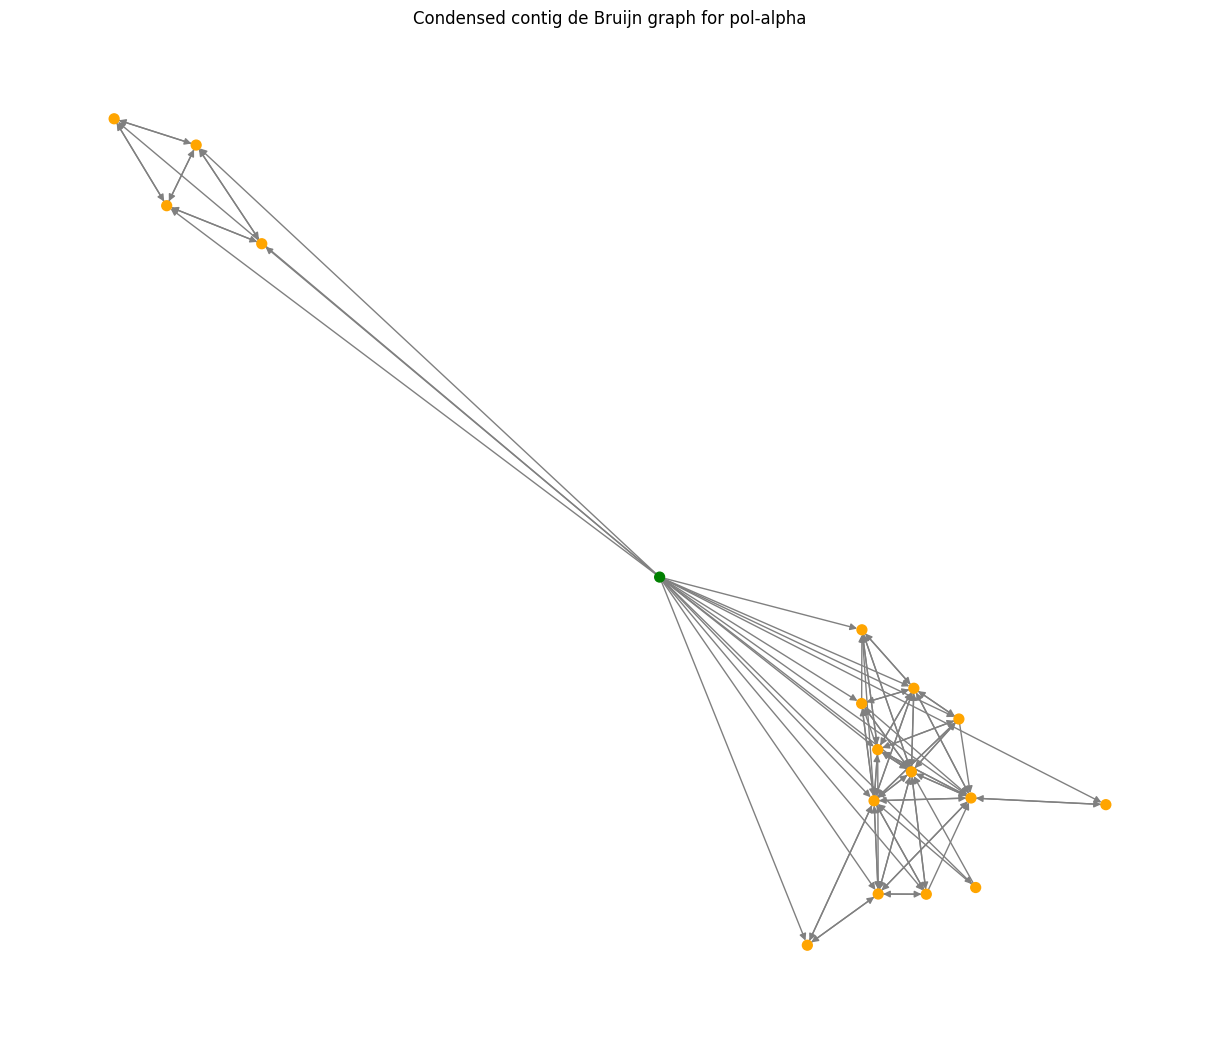

In [ ]:
# visualization for st kinase

import networkx as nx
import matplotlib.pyplot as plt

def build_condensed_contig_graph(H: AccumulatedDBG, reads: List[str]) -> nx.DiGraph:

  # Collapses paths into single contig nodes,
  # Returns a directed graph where each node is a contig/path

  G = H.graph

  unitig_paths = extract_potential_contigs(H)

  read_paths = extract_read_supported_paths(H, reads)
  branch_read_supported_paths = [path for path in read_paths if path_crosses_branch(H, path)]

  paths_with_class = ([('unitig', path) for path in unitig_paths] +
   [('branch_read_supported', path) for path in branch_read_supported_paths])

  C = nx.DiGraph()
  node_to_contig = {}

  for i, (path_class, path) in enumerate(paths_with_class):
    contig_id = f'{path_class}_{i}'
    seq = path_to_sequence(path, H.k)

    start_kmer = path[0]
    end_kmer = path[-1]

    C.add_node(contig_id,
               sequence = seq,
               length = len(seq),
               start_kmer = start_kmer,
               end_kmer = end_kmer,
               path = path,
               path_class = path_class)

    for node in path:
      node_to_contig[node] = contig_id

  for u, v in G.edges():
    cu = node_to_contig.get(u)
    cv = node_to_contig.get(v)

    if cu is None or cv is None:
      continue

    if cu != cv:
      if C.has_edge(cu, cv):
          C[cu][cv]['support'] += 1
      else:
        C.add_edge(cu, cv, support=1)

  return C

def best_window_identity(query_seq, target_seq):

  # compares contig sequence to reference sequence
  #to get contigs that share regions with reference locus

  query_seq = clean_seq(query_seq)
  target_seq = clean_seq(target_seq)

  qlen = len(query_seq)
  if qlen > len(target_seq):
    return 0

  best = 0
  for i in range(len(target_seq) - qlen + 1):
    window = target_seq[i:i+qlen]
    identity = sum(a == b for a, b in zip(query_seq, window)) / qlen
    best = max(best, identity)

  return best

def add_reference_backbone_by_kmers(C,
                                    reference_seq,
                                    k=25,
                                    min_shared_kmers=1,
                                    allow_rc=True,):
  # adds a backbone to the de Bruijn graph that is one node corresponding to reference sequence

  C2 = C.copy()
  ref_seq = clean_seq(reference_seq)

  ref_kmers = set(kmers(ref_seq, k))
  if allow_rc:
    ref_kmers |= set(kmers(rc(ref_seq), k))

  C2.add_node('reference',
              sequence=ref_seq,
              length=len(ref_seq),
              is_reference=True)

  for v in list(C.nodes()):
    contig_seq = clean_seq(C.nodes[v].get('sequence', ''))

    if len(contig_seq) < k:
      continue

    contig_kmers = set(kmers(contig_seq, k))
    shared = contig_kmers & ref_kmers

    if len(shared) >= min_shared_kmers:
      C2.add_edge('reference',
                  v,
                  support=len(shared),
                  shared_kmers=len(shared),)

  return C2


def plot_condensed_contig_graph(C: nx.DiGraph, figsize=(12, 10), with_labels=True):
  if C.number_of_nodes() == 0:
    print('Condensed graph is empty')
    return

  # colors nodes by branching behavior
  colors = []
  sizes = []

  for v in C.nodes():
    if v == 'reference' or C.nodes[v].get('is_reference', False): # reference contig is green
      colors.append('green')
      sizes.append(800)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)
    length = C.nodes[v].get('length', 1)

    if indeg == 1 and outdeg == 1:
      colors.append('lightgray')
    elif indeg == 0 or outdeg == 0:
      colors.append('red')
    else:
      colors.append('orange')

    sizes.append(max(300, min(3000, length * 20)))

  plt.figure(figsize=figsize)
  pos = nx.spring_layout(C, seed=1)

  nx.draw(C,
          pos,
          node_color = colors,
          node_size = 50,
          edge_color= 'gray',
          with_labels = False,
          arrows=True,)

  plt.title('Condensed contig de Bruijn graph for pol-alpha')
  plt.show()

def reference_connected_subgraph(C_ref: nx.DiGraph, reference_node='reference') -> nx.DiGraph:
  if reference_node not in C_ref:
    print(f'{reference_node} not found')
    return nx.DiGraph()

  ref_neighbors = set(C_ref.successors(reference_node))
  keep = {reference_node} | ref_neighbors

  return C_ref.subgraph(keep).copy()


H = result['final_graph']
C = build_condensed_contig_graph(H, combined_reads)

C_ref = add_reference_backbone_by_kmers(C,
                                        locus_reference_seq,
                                        k=25,
                                        min_shared_kmers=1,
                                        allow_rc=True,)

def remove_terminal_contigs(C: nx.DiGraph, preserve_reference: bool = True) -> nx.DiGraph:

  # keep only internally connected contigs

  keep = []

  for v in C.nodes():
    if preserve_reference and (v == 'reference' or C.nodes[v].get('is_reference', False)):
      keep.append(v)
      continue

    indeg = C.in_degree(v)
    outdeg = C.out_degree(v)


    if indeg > 0 and outdeg > 0:
      keep.append(v)

  return C.subgraph(keep).copy()

C_ref_only = reference_connected_subgraph(C_ref)

C_ref_internal = remove_terminal_contigs(C_ref_only)

print('reference-connected contigs:', C_ref_internal.number_of_nodes() - 1)
print('reference-connected edges:', C_ref_internal.number_of_edges())

plot_condensed_contig_graph(C_ref_internal, with_labels=False)






# Bayesian Scoring Model
source code heavily based on https://www.geeksforgeeks.org/machine-learning/ (for graphs) implementation-of-bayesian-regression/ and especially https://pyro.ai/examples/bayesian_regression.html#Bayesian-Regression-with-Pyro's-Stochastic-Variational-Inference-%28SVI%29 (for model), but adapted to create a probabilistic scoring model rather than a linear regression model

In [ ]:
#import the model
!pip install pyro-ppl
import torch
from torch import nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam
from pyro.nn import PyroModule, PyroSample
import matplotlib.pyplot as plt
import seaborn as sns
import re
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pyro.set_rng_seed(100)
torch.manual_seed(100)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 19.0 MB/s eta 0:00:00
Using device: cuda


In [ ]:
#taking in/processing edges as data

def edge_data(H: AccumulatedDBG, MAC_reference_seq: str, MIC_reference_seq_list: list, MDSs_sequences):
  X = []
  Y = []
  MAC_ref_seq = clean_seq(MAC_reference_seq)
  MAC_kmers = set(kmers(MAC_ref_seq, H.k)) | set(kmers(rc(MAC_ref_seq), H.k))

  MIC_kmers=set()
  for contig in MIC_reference_seq_list:
    MIC_ref_seq = clean_seq(contig)
    MIC_kmers |= set(kmers(MIC_ref_seq, H.k)) | set(kmers(rc(MIC_ref_seq), H.k))


  for u, v, attrs in H.graph.edges(data=True):
    u_in_MAC = 1 if u in MAC_kmers else 0
    v_in_MAC = 1 if v in MAC_kmers else 0
    u_in_MIC = 1 if u in MIC_kmers else 0
    v_in_MIC = 1 if v in MIC_kmers else 0

    intact_mac = 0
    if u_in_MAC == 1:
      results = [s for s in MDSs_sequences if u in s]
      for r in results:
        if  (r.endswith(u) == False):
          concat = u + v[-1]
          if concat not in r:
            intact_mac = -2
          else:
            intact_mac = 0
            break

    edge_support = attrs.get("support", 1) # Assuming support is always at least 1

    X.append([u_in_MAC, v_in_MAC, u_in_MIC, v_in_MIC, intact_mac, edge_support])
    Y.append(float(attrs.get("support", 0) > 0)) # Y is Bernoulli, so 1 if support > 0, 0 otherwise

  return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)


In [ ]:
class BayesianScoring(PyroModule):
    def __init__(self, in_features):
        super().__init__()

        self.linear = PyroModule[nn.Linear](in_features, 1)
        self.linear.weight = PyroSample(dist.Normal(torch.zeros(1, in_features, device=device), torch.ones(1, in_features, device=device)).to_event(2))
        self.linear.bias = PyroSample(dist.Normal(torch.zeros(1, device=device), torch.ones(1, device=device) * 10.).to_event(1))


    def forward(self, x, y=None):
        # Priors: initial probability of what the edges/junctions should look like (based off of pointers, perfect Mac, and scrambling)
        # sigma = pyro.sample("sigma", dist.Uniform(0., 10.))
        mean = self.linear(x).squeeze(-1)
        # Likelihood:  the probability of our read counts based on whether the edge exists or not

        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(probs=torch.sigmoid(mean)), obs=y) #edge either exists or not, so this is bernoulli distribution
        return mean

In [ ]:
#defining the variational guide
# posterior parameters
# Posterior: returns probability of each edge being real after taking into account both prior and likelihood
from pyro.infer.autoguide import AutoDiagonalNormal
model = BayesianScoring(6)
guide = AutoDiagonalNormal(model)


training and running the model. This will by default train the model for the serine_threonine gene. If you want to run the model for another gene please run that gene's debruijn graph cells first.

In [ ]:
#training
x_data, y_data = edge_data(H, locus_reference_seq, MIC_reference_seq, MDSs_sequences)

x_data = x_data.to(device)
y_data = y_data.to(device)

model.to(device)

optim = Adam({"lr": 0.03})
svi = SVI(model, guide, optim, loss=Trace_ELBO())

num_iterations = 1000
for i in range(num_iterations):
    loss = svi.step(x_data, y_data)
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1} - Loss: {loss}/{len(y_data)}")


Iteration 100 - Loss: 2707.666761159897/176450
Iteration 200 - Loss: 1224.184755206108/176450
Iteration 300 - Loss: 687.4396028518677/176450
Iteration 400 - Loss: 445.22058486938477/176450
Iteration 500 - Loss: 346.4277163743973/176450
Iteration 600 - Loss: 251.9993896484375/176450
Iteration 700 - Loss: 174.8887533545494/176450
Iteration 800 - Loss: 157.752343416214/176450
Iteration 900 - Loss: 141.92845690250397/176450
Iteration 1000 - Loss: 118.5537097454071/176450


In [ ]:
def summary(samples):
    site_stats = {}
    for k, v in samples.items():
        site_stats[k] = {
            "mean": torch.mean(v, 0),
            "std": torch.std(v, 0),
            "5%": v.kthvalue(int(len(v) * 0.05), dim=0)[0],
            "95%": v.kthvalue(int(len(v) * 0.95), dim=0)[0],
        }
    return site_stats


In [ ]:
#posterior estimates
predictive = Predictive(model, guide=guide, num_samples=1000)
posterior = predictive(x_data)
edge_existence_probs=posterior["obs"].mean(dim=0)
pred_summary = summary(posterior)

mu= pred_summary["obs"]["mean"]
y = pred_summary["obs"]

predictions = pd.DataFrame({
    "u_in_MAC": x_data[:, 0].cpu(),
    "v_in_MAC": x_data[:, 1].cpu(),
    "u_in_MIC": x_data[:, 2].cpu(),
    "v_in_MIC": x_data[:, 3].cpu(),
    "intact_mac": x_data[:, 4].cpu(),
    "edge_support_feature": x_data[:, 5].cpu(),
    "predicted_prob_mean": mu.cpu(),
    "predicted_prob_perc_5": y["5%"].cpu(),
    "predicted_prob_perc_95": y["95%"].cpu(),
    "true_existence_label": y_data.cpu(),
})

slope_samples = posterior["linear.weight"]
intercept_samples = posterior["linear.bias"]

# posterior mean estimates
slope_mean = slope_samples.mean()
intercept_mean = intercept_samples.mean()

print("\nEstimated Parameters:")
print("Estimated Slope (mean of coefficients):", round(slope_mean.item(), 4))
print("Estimated Intercept:", round(intercept_mean.item(), 4))


Estimated Parameters:
Estimated Slope (mean of coefficients): 0.8524
Estimated Intercept: 4.2211


visualization

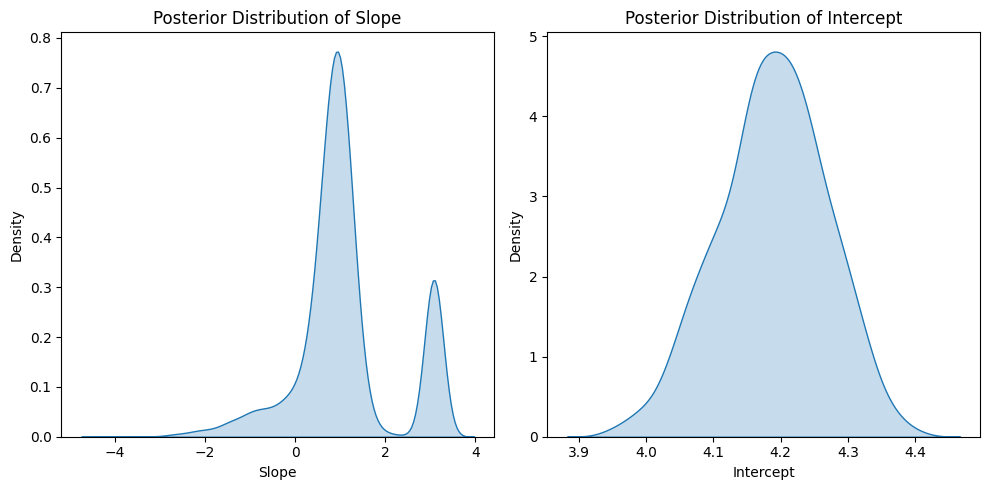

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # Create subplots, adjusted from 1,3 to 1,2 as sigma plot was removed

# Plot the posterior distribution of the slope
sns.kdeplot(slope_samples.flatten().cpu(), fill=True, ax=axs[0])
axs[0].set_title("Posterior Distribution of Slope")
axs[0].set_xlabel("Slope")
axs[0].set_ylabel("Density")

# Plot the posterior distribution of the intercept
sns.kdeplot(intercept_samples.flatten().cpu(), fill=True, ax=axs[1])
axs[1].set_title("Posterior Distribution of Intercept")
axs[1].set_xlabel("Intercept")
axs[1].set_ylabel("Density")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

#Path Summation
getting the sum of edge probabilities per path and then ranking them

In [ ]:
def edge_sum(path, H, prob_dict):
  edges = list(zip(path[:-1], path[1:]))
  return sum([prob_dict[edge] for edge in edges])


edge_prob_dict = dict(zip(H.graph.edges(), edge_existence_probs))
sum_paths = []
for path in read_paths:
  sum_score = sum(edge_prob_dict.get((path[i], path[i+1]), 0) for i in range(len(path)-1))
  sequence = path_to_sequence(path, H.k)
  num_edges = len(path) - 1
  normalized_score = sum_score / num_edges
  sum_paths.append((sequence, normalized_score.cpu().item()))
sorted_paths_df = pd.DataFrame(sum_paths, columns=['sequence', 'sum_score'])
sorted_paths_df = sorted_paths_df.sort_values(by='sum_score', ascending=False)

print(sorted_paths_df.head(20))

                                             sequence  sum_score
19  TATTTTCTTCATGAGCATCGATCCAATAGAATGATAACTATATTAT...   0.999923
22  TCCCAAAACCCCAAAACCCCTTAACTCAATTTTATATGATATCATG...   0.999899
5   TTAGGTTTACCATCAAGTTTTCAATAAATAATAGATGTAGATAAGT...   0.999874
23  TCCCAAAACCCCAAAACCCCTTAACTCAATTTTATATGATATCATG...   0.999831
14  TTTAATGCATGCATACAACAACTATTTTTCATCTTTCACCAATATC...   0.999816
10  TCCCCAAAACCCCAAACCCCATAATTTAAATTAATTTATGAATTGT...   0.999808
16  TTGATATAGTGCTCACATATTAACTCTGATTAAAACAAAATATAAT...   0.999796
7   TCACTTTAATTTAAGGATTCGCTACTTTTAGCATCGAAATAACTTG...   0.999792
1   TACCCCAAAACCCCAAAACCCCTAGATATTTAGTGAAAATTATTTA...   0.999771
17  TTTAATGCATGCATACAACAACTATTTTTCATCTTTTCACCAATAT...   0.999770
20  AACCCCAAAACCCCAAAATTATTTAAAGCTGAGTATGTATGGTTGC...   0.999760
15  ATTTTCTTCATGAGCATCGATCCAATTGAATGATAACTATATTATA...   0.999697
8   TCCCAAAACCCCAAAAACCCCATAATTTAAATTAATTTATGAATTG...   0.999632
18  TCCCCAAAACCCCAAAACCCAAAACCCCAAAACCCCAAAACCCCAA...   0.999597
26  TAAAGATTAAATAATAATACA